# **Project Name**    - Distributed Banking Analytics & ML System for Customer Subscription Prediction



##### **Project Type**    - Classification
##### **Contribution**    - Individual


# **Project Summary -**

# Project Summary

## Distributed Banking Analytics & ML System for Customer Subscription Prediction

This project focuses on building a distributed machine learning system for banking analytics using big data technologies such as Apache Hadoop, Hive, Apache Spark, Spark ML, and Spark Streaming.

The system processes large-scale banking customer data stored in the **bank.csv** dataset to analyze customer behavior, identify patterns, and generate predictive insights. The project demonstrates how distributed computing can efficiently manage and process high-volume banking data that traditional systems struggle to handle.

The workflow begins with storing banking data in Hadoop HDFS for distributed storage. Hive is used for structured querying and large-scale data access. Apache Spark performs distributed exploratory data analysis (EDA), feature processing, and scalable computation across data partitions.

Using Spark ML, machine learning models are developed to predict whether a customer will subscribe to a term deposit based on factors such as balance, loan status, contact duration, campaign history, and previous outcomes.

The project also includes Spark Streaming to simulate real-time transaction analysis and continuous data monitoring. This enables live processing for use cases such as fraud detection, suspicious activity monitoring, and real-time banking insights.

Additionally, the project applies data parallelism techniques to improve scalability, processing speed, and distributed execution efficiency for large banking datasets.

Overall, the project demonstrates the integration of distributed storage, parallel data processing, scalable machine learning, and real-time streaming within a modern banking analytics environment.


# **GitHub Link -**

Provide your GitHub Link here.

https://github.com/Rohan1-tech/Distributed-Banking-Analytics-And-ML-System

# **Problem Statement**


**Write Problem Statement Here.**

# Problem Statement

Modern banking institutions generate massive volumes of customer and transaction data every day. This data includes customer demographics, account balances, loan information, marketing campaign records, and transaction activities. Traditional data processing systems are often unable to efficiently handle the growing volume, variety, and velocity of this banking data.

Banks require scalable systems that can store, process, analyze, and monitor large datasets in real time to support better decision-making, customer analysis, fraud monitoring, and predictive analytics. Processing such data on a single machine leads to performance limitations, slower computations, and difficulties in real-time analysis.

The main problem addressed in this project is how to efficiently manage and analyze large-scale banking data using distributed machine learning and big data technologies.

The project aims to:

* store and manage banking data using distributed storage systems,
* perform large-scale exploratory data analysis,
* build scalable machine learning models for customer behavior prediction,
* process simulated real-time banking transactions,
* and improve processing efficiency using data parallelism techniques.

Using Apache Hadoop, Hive, Apache Spark, Spark ML, and Spark Streaming, the project demonstrates how distributed computing systems can transform large banking datasets into actionable insights while supporting scalability, speed, and real-time analytics.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

### Dataset Loading

In [2]:
# Load Dataset

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Dataset First View

In [3]:
# Dataset First Look

df = pd.read_csv('/content/drive/MyDrive/Data/bank .csv')


In [4]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 4521
Number of Columns : 17


### Dataset Information

In [6]:
# Dataset Info

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB
None


#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count

print(df.duplicated().sum())

0


#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count

print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


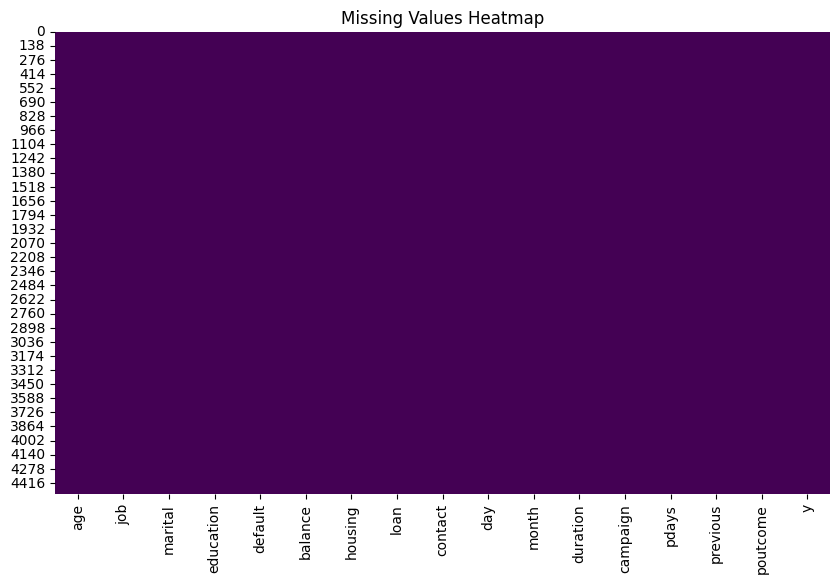

In [9]:
# Visualizing the missing values

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title('Missing Values Heatmap')
plt.show()

### What did you know about your dataset?

Answer Here


The banking dataset consists of **4521 records and 17 features**, containing both numerical and categorical variables. The dataset includes customer demographic details, financial information, loan-related attributes, and marketing campaign interaction data.

This dataset structure makes it suitable for:

* Exploratory Data Analysis (EDA)
* Customer behavior analysis
* Binary classification modeling
* Distributed data processing
* Banking analytics workflows

---


**1. Missing Values Analysis**

The dataset does not contain any missing or null values across any of the features.

 **Benefits:**

* No missing-value treatment or imputation required
* Simplifies preprocessing workflow
* Improves data consistency
* Supports stable machine learning model training

---

**2. Duplicate Records Analysis**

No duplicate records were identified in the dataset.

**Benefits:**

* Ensures data integrity
* Improves analytical accuracy
* Prevents biased model training
* Maintains reliable statistical analysis

---

**Feature Understanding**

The dataset contains multiple categories of banking-related features that help analyze customer behavior and campaign effectiveness.

---

**Customer Demographic Features**

These attributes describe the personal background of customers:

* Age
* Job Type
* Marital Status
* Education Level

These features are useful for identifying customer segments and behavioral patterns.

---

 **Financial Features**

These attributes represent the financial condition and loan-related information of customers:

* Account Balance
* Housing Loan Status
* Personal Loan Status
* Credit Default History

These variables help analyze customer financial behavior and risk-related patterns.

---

**Marketing Campaign Features**

These features contain information related to banking campaign interactions:

* Contact Communication Type
* Contact Day and Month
* Call Duration
* Campaign Contact Count
* Previous Contact History
* Previous Campaign Outcome

These variables are important for evaluating campaign performance and customer engagement.

---

**Target Variable**

The target variable in the dataset is:

```python id="2bwn72"
y
```

The variable indicates whether a customer subscribed to a term deposit.

 **Possible Outcomes:**

* Yes
* No

This confirms that the project is a **binary classification problem**.

---

**Overall Dataset Understanding**

From the analysis, it was observed that customer subscription behavior may be influenced by:

* financial status,
* loan information,
* communication history,
* campaign interactions,
* and previous marketing outcomes.

Overall, the dataset is well-structured, clean, and highly suitable for distributed machine learning, scalable analytics, and banking customer behavior prediction tasks.


## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns

print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')


In [11]:
# Dataset Describe

df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


### Variables Description

Answer Here

| Variable  | Description                                                                                                                                     |
| --------- | ----------------------------------------------------------------------------------------------------------------------------------------------- |
| age       | Age of the customer                                                                                                                             |
| job       | Type of job or occupation of the customer                                                                                                       |
| marital   | Marital status of the customer                                                                                                                  |
| education | Education qualification level                                                                                                                   |
| default   | Indicates whether the customer has credit in default                                                                                            |
| balance   | Average yearly account balance of the customer                                                                                                  |
| housing   | Indicates whether the customer has a housing loan                                                                                               |
| loan      | Indicates whether the customer has a personal loan                                                                                              |
| contact   | Type of communication used to contact the customer                                                                                              |
| day       | Last contact day of the month                                                                                                                   |
| month     | Last contact month of the year                                                                                                                  |
| duration  | Duration of the last contact call in seconds                                                                                                    |
| campaign  | Number of contacts performed during the current campaign for the customer                                                                       |
| pdays     | Number of days passed after the customer was last contacted from a previous campaign (`-1` indicates the customer was not previously contacted) |
| previous  | Number of contacts performed before the current campaign                                                                                        |
| poutcome  | Outcome of the previous marketing campaign                                                                                                      |
| y         | Target variable indicating whether the customer subscribed to a term deposit                                                                    |


### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.

for column in df.columns:
    print(f"Unique values in {column}:")
    print(df[column].unique())
    print("-" * 50)

Unique values in age:
[30 33 35 59 36 39 41 43 20 31 40 56 37 25 38 42 44 26 55 67 53 68 32 49
 78 23 52 34 61 45 48 57 54 63 51 29 50 27 60 28 21 58 22 46 24 77 75 47
 70 65 64 62 66 19 81 83 80 71 72 69 79 73 86 74 76 87 84]
--------------------------------------------------
Unique values in job:
['unemployed' 'services' 'management' 'blue-collar' 'self-employed'
 'technician' 'entrepreneur' 'admin.' 'student' 'housemaid' 'retired'
 'unknown']
--------------------------------------------------
Unique values in marital:
['married' 'single' 'divorced']
--------------------------------------------------
Unique values in education:
['primary' 'secondary' 'tertiary' 'unknown']
--------------------------------------------------
Unique values in default:
['no' 'yes']
--------------------------------------------------
Unique values in balance:
[ 1787  4789  1350 ...  -333 -3313  1137]
--------------------------------------------------
Unique values in housing:
['no' 'yes']
------------------

## 3. ***Data Wrangling***

### Data Wrangling Code

* Check Data Types

In [13]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


* Standardize Column Names

In [14]:
df.columns = df.columns.str.lower().str.strip()

* Check Inconsistent Categories

In [15]:
for col in df.select_dtypes(include='object').columns:
    print(col)
    print(df [col].value_counts())
    print("-"*50)

job
job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: count, dtype: int64
--------------------------------------------------
marital
marital
married     2797
single      1196
divorced     528
Name: count, dtype: int64
--------------------------------------------------
education
education
secondary    2306
tertiary     1350
primary       678
unknown       187
Name: count, dtype: int64
--------------------------------------------------
default
default
no     4445
yes      76
Name: count, dtype: int64
--------------------------------------------------
housing
housing
yes    2559
no     1962
Name: count, dtype: int64
--------------------------------------------------
loan
loan
no     3830
yes     691
Name: count, dtype: int64
--------------------------------------------------
conta

*  Encoding Target Variable for Statistical Analysis & Machine Learning

In [16]:
# Convert yes/no into numerical values

df['y_num'] = df['y'].map({'yes': 1, 'no': 0})

* Handle Special Values

In [17]:
# -1 in pdays means customer was never contacted before

# Replace -1 with 0 for cleaner representation
df['pdays'] = df['pdays'].replace(-1, 0)

print("pdays unique values after replacement:")
print(df['pdays'].value_counts().head())

pdays unique values after replacement:
pdays
0      3705
182      23
183      20
363      12
92       12
Name: count, dtype: int64


* Outlier Analysis

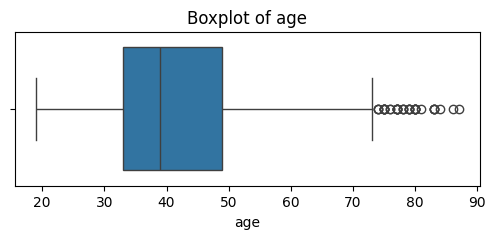

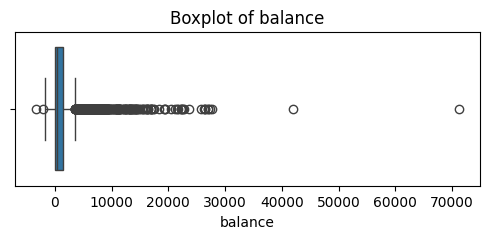

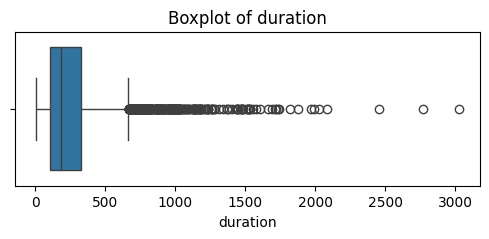

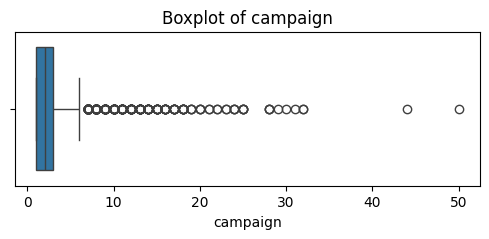

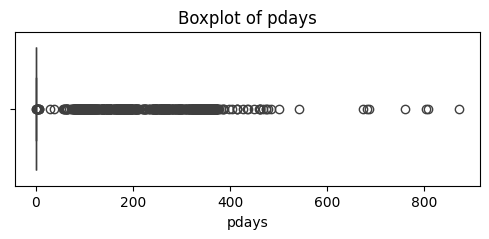

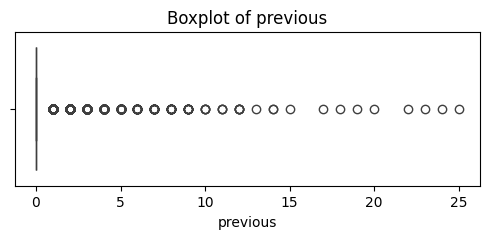

In [18]:
numerical_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


## Observations

**1. Age**

A few higher-age outliers were observed, mainly representing senior customers. These values appear realistic and were retained.

**2. Balance**

The balance feature contains several high-value outliers. Since banking customers may naturally maintain large account balances, these observations were preserved.

**3. Duration**

The duration feature shows long customer call durations, which may indicate strong customer engagement during marketing campaigns.

**4. Campaign**

Some customers were contacted multiple times during campaigns. These values were treated as meaningful campaign interaction records.

 **5. pdays**

The pdays feature contains customers contacted after long intervals from previous campaigns. These observations were retained as valid historical interaction data.

**6. Previous**

A few customers had higher numbers of previous contacts, representing historical campaign activity.


**Final Conclusion**

Although outliers were identified in multiple numerical features, the observations appeared realistic within the banking domain. Therefore, no aggressive outlier removal was performed to preserve meaningful customer behavior patterns.




### What all manipulations have you done and insights you found?

Answer Here.




**Data Manipulation and Preprocessing**

Several data wrangling and preprocessing techniques were applied to prepare the banking dataset for distributed analytics and machine learning workflows. The primary objective of these manipulations was to improve data quality, ensure consistency, and enhance the overall reliability of the analysis.

---

**1. Dataset Inspection and Structure Analysis**

Initial dataset exploration was performed to understand:

* dataset dimensions,
* feature distributions,
* data types,
* and overall dataset structure.

Functions such as:

* `df.shape`
* `df.info()`
* `df.describe()`

were used to analyze the dataset characteristics.

**Insight**

The dataset contains 4521 records and 17 features, including both numerical and categorical variables, making it suitable for customer behavior analysis and classification tasks.

---

**2. Missing Value Analysis**

A missing value check was conducted across all features to identify incomplete records.

**Observation**

No missing or null values were identified in the dataset.

**Insight**

The dataset was already clean and complete, reducing the need for additional missing-value treatment and improving preprocessing efficiency.

---

**3. Duplicate Record Analysis**

Duplicate records were analyzed to ensure dataset integrity and avoid biased analytical results.

**Observation**

No duplicate rows were detected.

 **Insight**

The absence of duplicate records improved data reliability and maintained consistency for further distributed processing and machine learning tasks.

---

**4. Categorical Feature Consistency Validation**

Categorical variables were analyzed using frequency distributions to identify:

* inconsistent labels,
* hidden formatting issues,
* and irregular category representations.

**Observation**

The categorical features were properly standardized and did not contain major inconsistencies.

**Insight**

The dataset demonstrated good categorical consistency, supporting efficient preprocessing and encoding operations for machine learning workflows.

---

**5. Handling Special Values in `pdays`**

The `pdays` feature contained `-1` values representing customers who were not contacted previously.

**Manipulation Performed**

The special value `-1` was replaced with `0` to provide a cleaner and more interpretable numerical representation.

**Insight**

This transformation improved feature consistency and simplified downstream analytical and machine learning processes.

---

**6. Outlier Analysis**

Outlier analysis was conducted on numerical variables using boxplot visualizations.

The following features were analyzed:

* age
* balance
* duration
* campaign
* pdays
* previous

**Observation**

Several numerical features contained extreme values, particularly in:

* account balance,
* campaign duration,
* and customer contact history.

**Insight**

The identified outliers appeared to represent realistic banking behavior rather than data-entry anomalies. Since these values may contain important customer and financial information, no aggressive outlier removal was performed.

This approach helped preserve the authenticity of real-world banking patterns within the dataset.

---

**7. Feature Understanding and Behavioral Analysis**

Both demographic and campaign-related features were analyzed to better understand customer behavior and banking trends.

**Insight**

Features related to:

* financial status,
* loan information,
* campaign interaction,
* and communication history

appear to have potential influence on customer subscription behavior.

---

**8. Target Variable Analysis**

The target variable `y` was analyzed to understand customer subscription distribution.

**Observation**

The dataset is imbalanced, with a significantly higher number of customers not subscribing to the term deposit compared to successful subscriptions.

**Insight**

This class imbalance is an important consideration for machine learning model development and evaluation.


----

**Key Insights Identified**

The preprocessing and exploratory analysis phase revealed several important insights:

* The dataset is clean, structured, and suitable for distributed machine learning workflows.
* Financial and campaign-related features may strongly influence customer subscription outcomes.
* High account balances and longer communication durations appear significant in customer engagement.
* Customer contact history and previous campaign outcomes may contribute to subscription prediction.
* The dataset is appropriate for scalable analytics using Hadoop, Hive, Apache Spark, Spark ML, and Spark Streaming.



## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

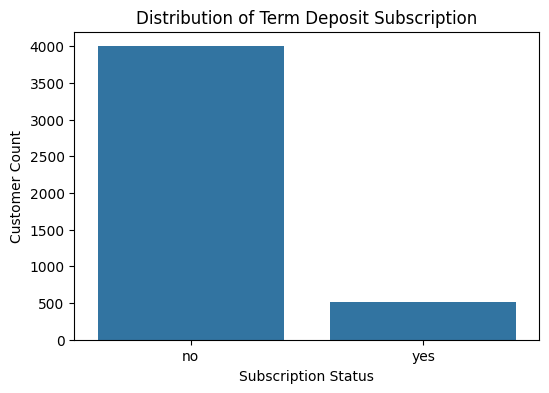

In [19]:
# Chart - 1 Distribution of Term Deposit Subscription

plt.figure(figsize=(6,4))

sns.countplot(x='y', data=df)

plt.title('Distribution of Term Deposit Subscription')
plt.xlabel('Subscription Status')
plt.ylabel('Customer Count')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A count plot was selected because it is the most suitable visualization for displaying the frequency distribution of categorical variables.

This chart clearly shows the number of customers who subscribed and did not subscribe to the term deposit, making it easier to understand the target variable distribution.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The chart shows that the majority of customers did not subscribe to the term deposit, while only a smaller number of customers subscribed successfully.

This indicates that the dataset is imbalanced, with the no category significantly larger than the yes category.

The observation suggests that customer conversion rates for term deposit subscriptions are relatively low.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Yes, the insights can help create a positive business impact.
The chart helps banks understand customer subscription behavior and campaign effectiveness. By identifying the low subscription rate, banks can improve:


* customer targeting strategies,


* marketing campaign planning,


* and customer engagement approaches.


These insights can help reduce unnecessary marketing costs and improve future campaign success rates.

#### Chart - 2

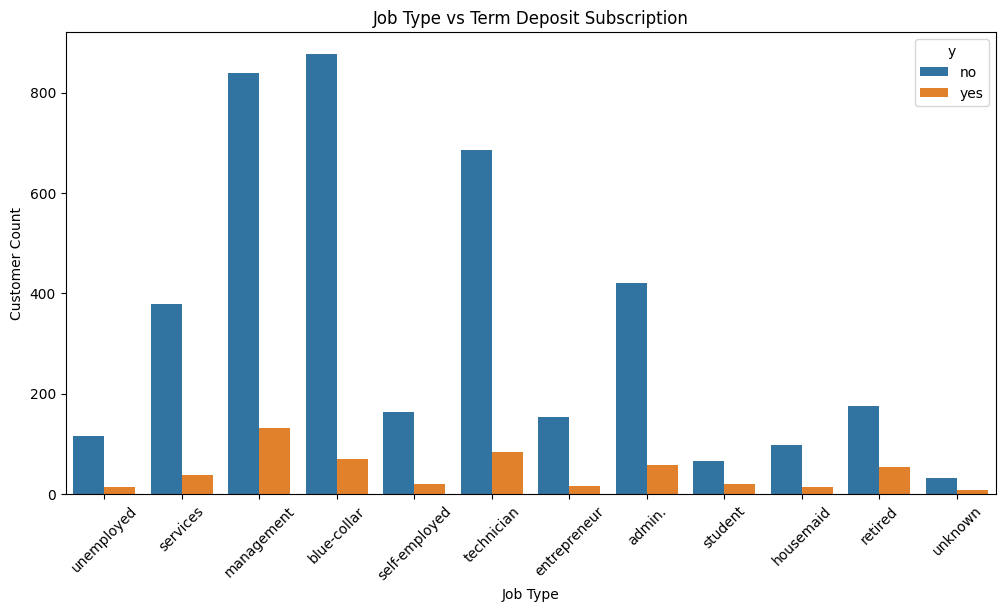

In [20]:
# Chart - 2 Job Type vs Term Deposit Subscription

plt.figure(figsize=(12,6))

sns.countplot(x='job', hue='y', data=df)

plt.title('Job Type vs Term Deposit Subscription')
plt.xlabel('Job Type')
plt.ylabel('Customer Count')

plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.


A count plot with a hue parameter was selected because it effectively compares customer subscription behavior across different job categories.

This chart helps analyze:

* which job groups are more likely to subscribe,
* customer segmentation patterns,
* and the relationship between occupation and term deposit subscriptions.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The chart shows that customers from certain job categories, such as management, technician, and admin-related professions, have higher participation in term deposit subscriptions compared to some other occupations.

It was also observed that blue-collar customers represent a large portion of the dataset but show comparatively lower subscription conversions.

This indicates that customer occupation may influence banking product engagement and campaign outcomes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Yes, the insights can help create a positive business impact.

Understanding subscription behavior across job categories can help banks:

* improve customer segmentation,
* create occupation-based marketing strategies,
* target high-potential customer groups more effectively,
* and optimize campaign performance.

#### Chart - 3

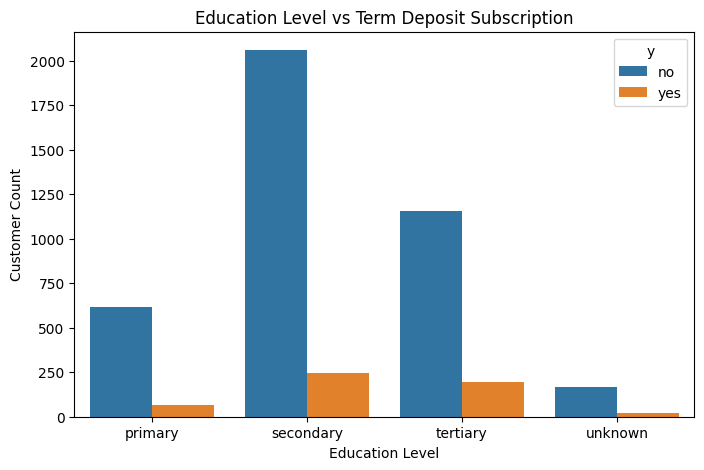

In [21]:
# Chart - 3 Education Level vs Term Deposit Subscription

plt.figure(figsize=(8,5))

sns.countplot(x='education', hue='y', data=df)

plt.title('Education Level vs Term Deposit Subscription')
plt.xlabel('Education Level')
plt.ylabel('Customer Count')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.


A count plot was used to compare term deposit subscription behavior across different education levels and identify customer distribution patterns.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The chart shows that customers with secondary and tertiary education levels form a large portion of the dataset and also contribute significantly to term deposit subscriptions.

Customers with tertiary education appear to show comparatively better subscription behavior than some other education categories.

This suggests that education level may influence customer awareness and engagement with banking products.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here


Yes, the insights can help create a positive business impact.

Understanding how education level affects customer subscription behavior can help banks:

* improve customer targeting strategies,
* design more personalized financial campaigns,
* and provide suitable banking products for different customer groups.

#### Chart - 4

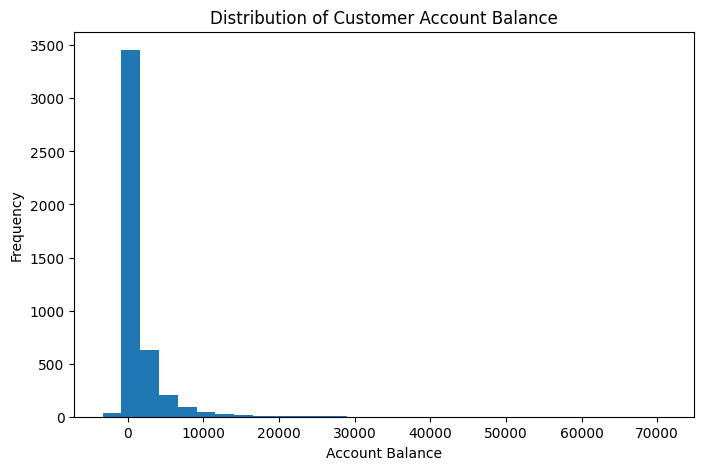

In [22]:
# Chart - 4 Distribution of Customer Account Balance

plt.figure(figsize=(8,5))

plt.hist(df['balance'], bins=30)

plt.title('Distribution of Customer Account Balance')
plt.xlabel('Account Balance')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A histogram was used to understand the distribution of customer account balances and identify how financial balances vary among customers.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The chart shows that most customers have lower account balances, while a smaller number of customers maintain very high balances.

This indicates that the balance feature is positively skewed, with a few customers contributing to extremely high balance values.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Yes, the insights can support better financial decision-making and customer targeting.

By understanding customer balance patterns, banks can:

* identify customers with higher financial capacity,
* improve marketing strategies for premium banking services,
* and develop personalized financial offers based on customer account behavior.

This can help improve customer engagement and increase the effectiveness of banking campaigns.

#### Chart - 5

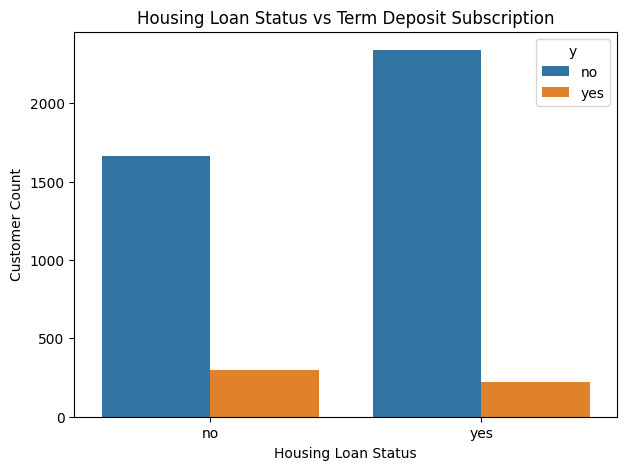

In [23]:
# Chart - 5 Housing Loan Status vs Term Deposit Subscription



plt.figure(figsize=(7,5))

sns.countplot(x='housing', hue='y', data=df)

plt.title('Housing Loan Status vs Term Deposit Subscription')
plt.xlabel('Housing Loan Status')
plt.ylabel('Customer Count')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

This visualization was used to compare customer subscription behavior based on housing loan status and identify differences between customer segments.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The chart shows that customers without housing loans demonstrate a relatively higher term deposit subscription rate compared to customers who already have housing loans.

This suggests that existing loan commitments may influence customer investment decisions and financial planning behavior.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Yes. The insights can help banks better understand customer financial behavior and improve customer segmentation strategies.

By identifying how housing loan status affects subscription behavior, banks can design more personalized marketing campaigns and improve customer targeting for financial products.

#### Chart - 6

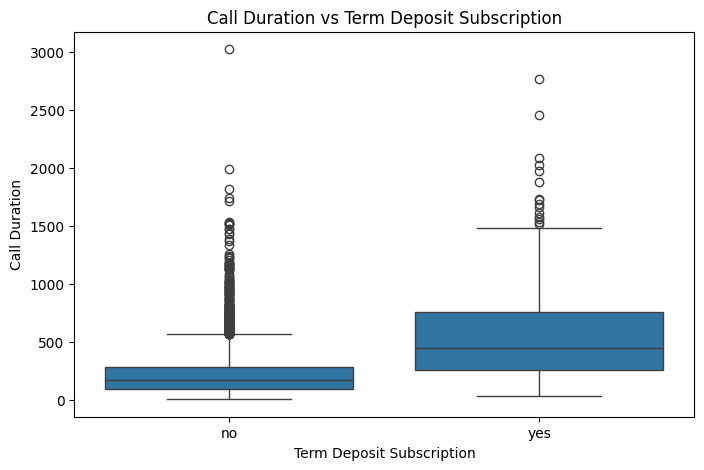

In [24]:
# Chart - 6 Call Duration vs Term Deposit Subscription

plt.figure(figsize=(8,5))

sns.boxplot(x='y', y='duration', data=df)

plt.title('Call Duration vs Term Deposit Subscription')
plt.xlabel('Term Deposit Subscription')
plt.ylabel('Call Duration')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A boxplot was used to compare the distribution of call durations between customers who subscribed and those who did not subscribe to the term deposit.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The chart shows that customers who subscribed to the term deposit generally had longer call durations compared to customers who did not subscribe.

This suggests that customer engagement during calls may strongly influence subscription outcomes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Yes. The insights can help banks understand the importance of customer interaction quality during marketing campaigns.

Longer and more effective customer conversations may improve subscription rates, helping banks optimize communication strategies and improve campaign performance.

#### Chart - 7

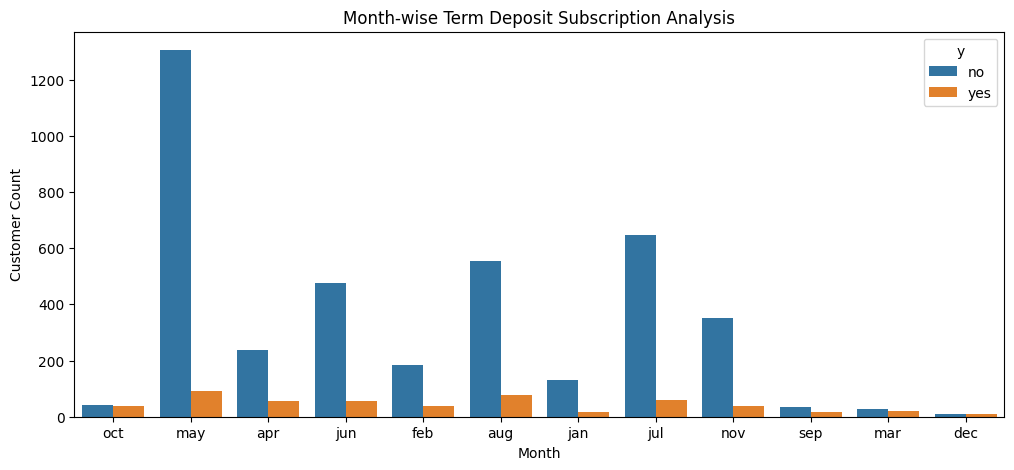

In [25]:
# Chart - 7   Month-wise Term Deposit Subscription Analysis

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

sns.countplot(x='month', hue='y', data=df)

plt.title('Month-wise Term Deposit Subscription Analysis')
plt.xlabel('Month')
plt.ylabel('Customer Count')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

This chart was used to analyze how customer subscription behavior changes across different months and identify seasonal campaign trends.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The chart shows that marketing campaign activity was higher during months such as May, July, and August.

It was also observed that subscription behavior varies across different months, indicating that campaign timing may influence customer responses.

This suggests the presence of seasonal trends in banking campaign performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Yes. The insights can help banks identify the most effective months for running marketing campaigns and customer engagement activities.

Understanding seasonal customer behavior can support better campaign planning, resource allocation, and improved marketing performance.

#### Chart - 8

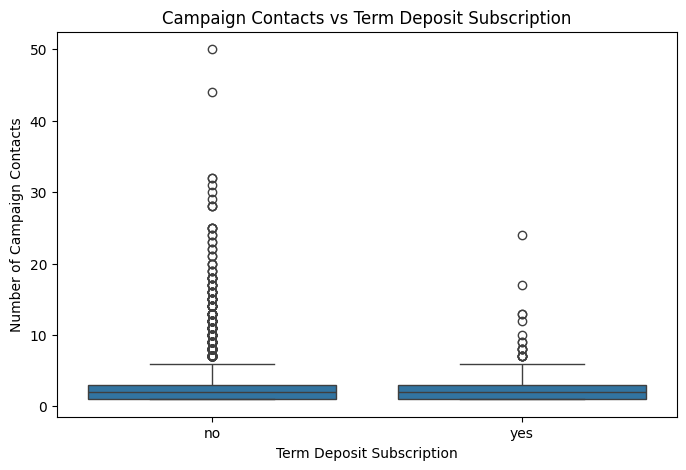

In [26]:
# Chart - 8 Campaign Contacts vs Term Deposit Subscription


plt.figure(figsize=(8,5))

sns.boxplot(x='y', y='campaign', data=df)

plt.title('Campaign Contacts vs Term Deposit Subscription')
plt.xlabel('Term Deposit Subscription')
plt.ylabel('Number of Campaign Contacts')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.


A boxplot was used to compare the number of campaign contacts between customers who subscribed and those who did not subscribe to the term deposit.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The chart shows that customers with a very high number of campaign contacts do not necessarily have higher subscription rates.

This suggests that repeatedly contacting customers may not always improve campaign success and could reduce customer engagement effectiveness.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Yes. The insights can help banks optimize marketing campaign strategies and reduce unnecessary customer contacts.

By understanding the relationship between campaign frequency and customer response, banks can improve communication efficiency and focus on higher-quality customer interactions.

#### Chart - 9

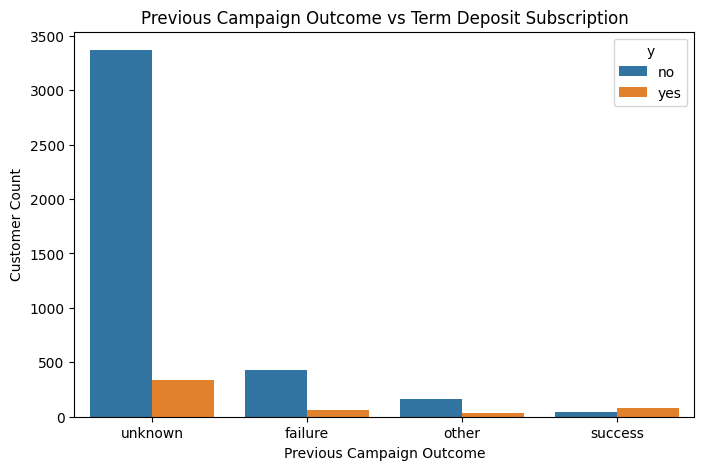

In [27]:
# Chart - 9 Previous Campaign Outcome vs Term Deposit Subscription

plt.figure(figsize=(8,5))

sns.countplot(x='poutcome', hue='y', data=df)

plt.title('Previous Campaign Outcome vs Term Deposit Subscription')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Customer Count')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

This chart was used to compare customer subscription behavior based on the outcomes of previous marketing campaigns.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The chart shows that customers with a successful previous campaign outcome have a noticeably higher likelihood of subscribing to a term deposit.

In contrast, customers with failed or unknown previous outcomes show lower subscription rates.

This indicates that previous customer engagement history may strongly influence future campaign success.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Yes. The insights can help banks identify customers who are more likely to respond positively to future marketing campaigns.

By using previous campaign outcomes for customer targeting, banks can improve campaign efficiency, increase conversion rates, and optimize marketing resources.

#### Chart - 10

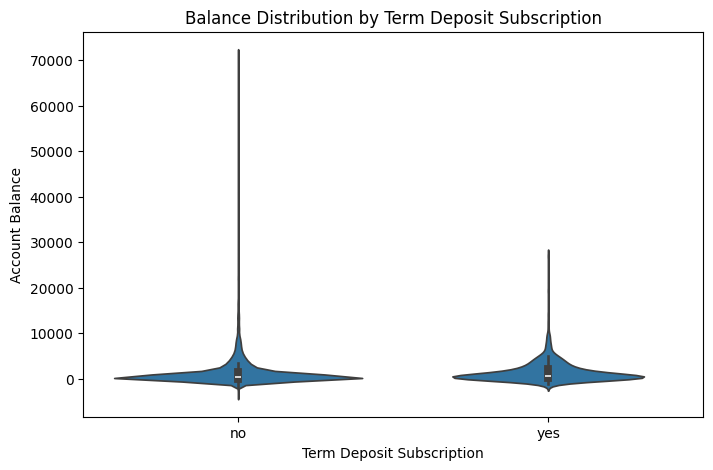

In [28]:
# Chart - 10 Balance Distribution by Term Deposit Subscription

plt.figure(figsize=(8,5))

sns.violinplot(x='y', y='balance', data=df)

plt.title('Balance Distribution by Term Deposit Subscription')
plt.xlabel('Term Deposit Subscription')
plt.ylabel('Account Balance')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A violin plot was used to compare the distribution and density of customer account balances across subscription categories.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The chart shows noticeable variation in account balance distributions between customers who subscribed and those who did not subscribe to the term deposit.

Customers with higher balances appear to show relatively stronger subscription behavior compared to customers with lower balances.

This suggests that financial capacity may influence customer investment decisions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here


Yes. The insights can help banks identify financially active customer groups and improve customer segmentation strategies.

Understanding balance-related customer behavior can support more targeted financial campaigns and improve the effectiveness of banking product recommendations.

#### Chart - 11

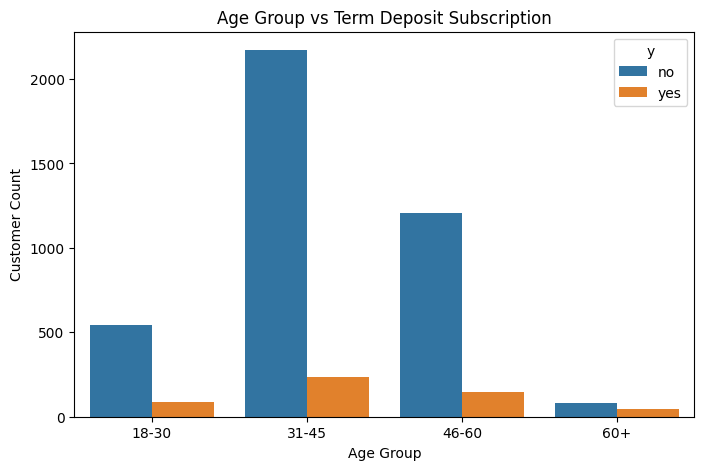

In [29]:
# Chart - 11 Age Group vs Term Deposit Subscription


# Create age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[18, 30, 45, 60, 100],
    labels=['18-30', '31-45', '46-60', '60+']
)

plt.figure(figsize=(8,5))

sns.countplot(x='age_group', hue='y', data=df)

plt.title('Age Group vs Term Deposit Subscription')
plt.xlabel('Age Group')
plt.ylabel('Customer Count')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

This chart was used to analyze customer subscription behavior across different age groups and identify demographic trends.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The chart shows that middle-aged customers, especially those between 31–45 years, represent a large portion of term deposit subscriptions.

Older customers also show noticeable subscription activity, while younger customers contribute comparatively less.

This suggests that age group plays an important role in banking product engagement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Yes. The insights can help banks develop age-specific marketing strategies and improve customer targeting.

By understanding which age groups are more likely to subscribe, banks can design more personalized financial products and optimize campaign effectiveness.

#### Chart - 12 - Correlation Heatmap

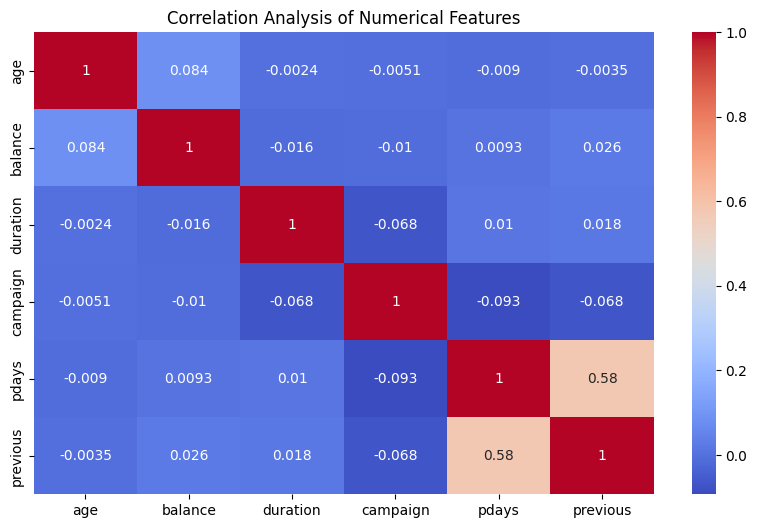

In [30]:
# Correlation Heatmap visualization code

plt.figure(figsize=(10,6))

corr_matrix = df[['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Analysis of Numerical Features')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A correlation heatmap was used to analyze relationships between numerical variables and identify correlation patterns within the dataset.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The heatmap shows that most numerical features have weak to moderate correlations with each other.

Some variables show slight positive relationships, while others have weak negative correlations. This indicates that the numerical features are relatively independent and contribute different information to the dataset.

#### Chart - 13 - Pair Plot

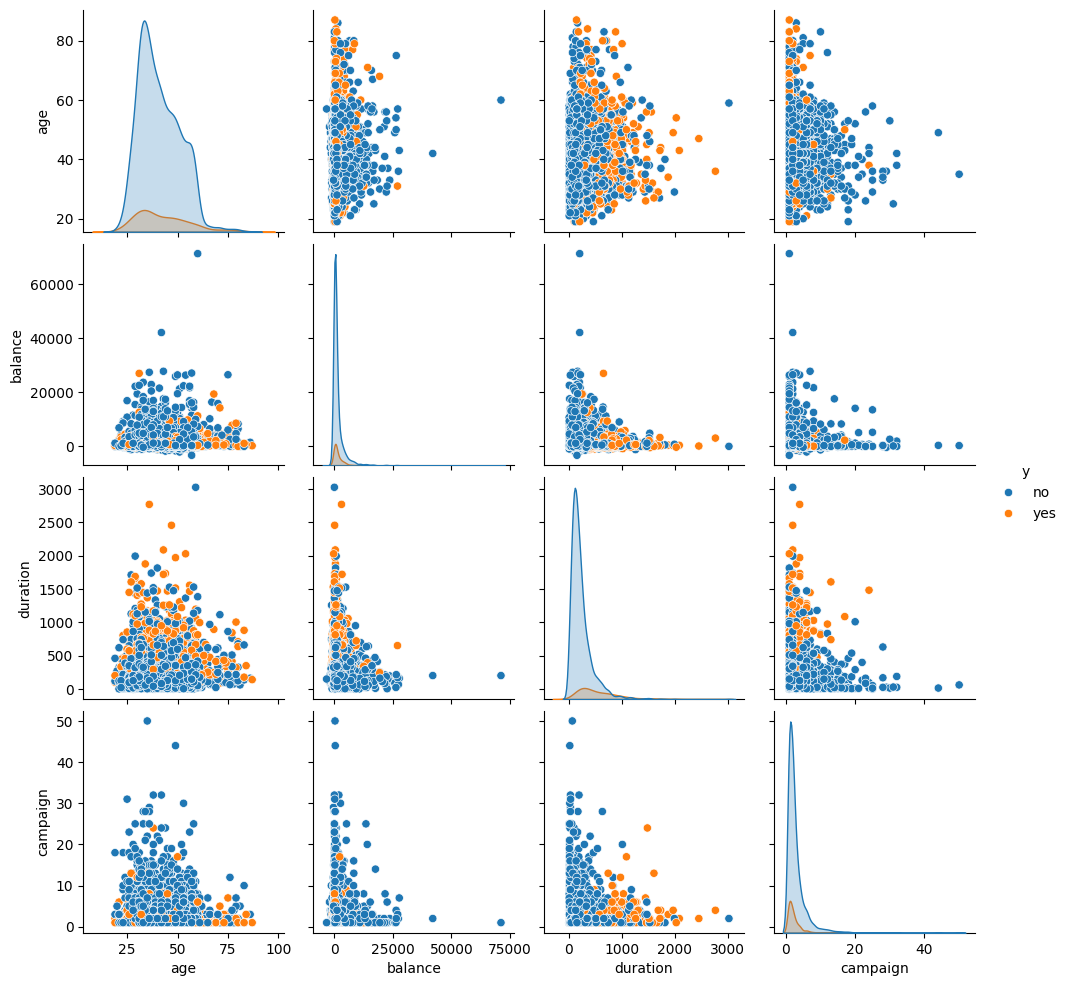

In [31]:
# Pair Plot visualization code

selected_features = ['age', 'balance', 'duration', 'campaign', 'y']

sns.pairplot(df[selected_features], hue='y')

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

A pair plot was used to analyze relationships between multiple numerical features simultaneously and observe how they interact with the target variable.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

The pair plot shows the distribution and interaction of important numerical variables such as age, balance, duration, and campaign count.

It was observed that:

* call duration shows noticeable variation between subscription categories,
* balance values vary significantly across customers,
* and most numerical features have relatively weak linear relationships with each other.

The visualization also helps identify data spread, clusters, and potential outliers.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

Based on the exploratory data analysis performed on the banking dataset, the following three hypothetical statements were defined for statistical hypothesis testing:

**Statement 1 — Call Duration & Subscription**
Customers with longer call durations are more likely to subscribe to a term deposit. The EDA boxplot and distribution charts revealed a noticeable difference in call duration between subscribed and non-subscribed customers, suggesting that longer interactions may indicate higher customer interest.

**Statement 2 — Job Type & Subscription**
A customer's job type has a significant relationship with their likelihood of subscribing to a term deposit. The bar chart analysis showed that certain job categories such as students and retired individuals had visibly higher subscription rates compared to other job types.

**Statement 3 — Previous Campaign Outcome & Subscription**
Customers who had a successful outcome in the previous marketing campaign are more likely to subscribe in the current campaign. The EDA analysis of the `poutcome` variable showed that customers with a prior success had a much higher subscription rate compared to those with unknown or failed outcomes.

These three statements were selected because they are directly supported by visual patterns observed during the EDA phase and cover a mix of both numerical and categorical variable relationships, allowing the use of different statistical tests such as the T-Test and Chi-Square Test for comprehensive hypothesis validation.



### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

**Hypothetical Statement 1:**
Customers with longer call durations are more likely to subscribe to a term deposit than customers with shorter call durations.


**Null Hypothesis (H0):**
There is no significant difference in the average call duration between customers who subscribed to a term deposit and those who did not.


**Alternate Hypothesis (H1):**
Customers who subscribed to a term deposit have a significantly higher average call duration compared to customers who did not subscribe.

#### 2. Perform an appropriate statistical test.

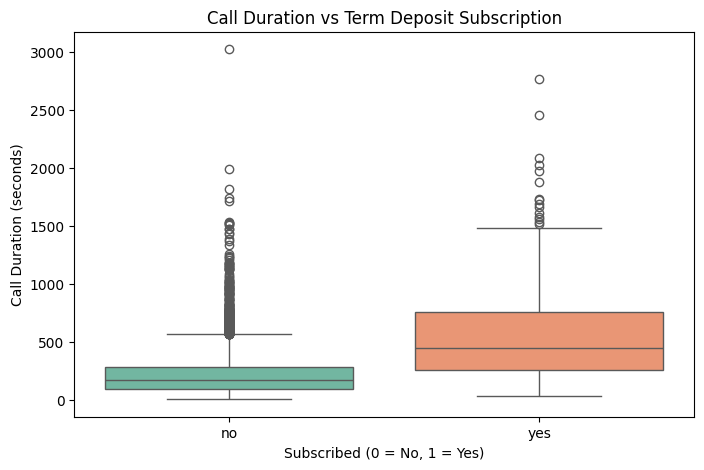

Mean duration (Subscribed): 552.74 seconds
Mean duration (Not Subscribed): 226.35 seconds


In [32]:
# Separate duration based on subscription status
subscribed = df[df['y'] == 'yes']['duration']
not_subscribed = df[df['y'] == 'no']['duration']

# Visualize
plt.figure(figsize=(8, 5))
sns.boxplot(x='y', y='duration', data=df, palette='Set2')
plt.title('Call Duration vs Term Deposit Subscription')
plt.xlabel('Subscribed (0 = No, 1 = Yes)')
plt.ylabel('Call Duration (seconds)')
plt.show()

print(f"Mean duration (Subscribed): {subscribed.mean():.2f} seconds")
print(f"Mean duration (Not Subscribed): {not_subscribed.mean():.2f} seconds")

In [33]:
# Perform Statistical Test to obtain P-Value

# Independent Sample T-Test
t_stat, p_value = stats.ttest_ind(subscribed, not_subscribed)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.6f}")

# Conclusion
alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject the Null Hypothesis")
    print("Conclusion: There Is a significant difference in call duration between subscribed and non-subscribed customers.")
else:
    print("\nResult: Fail to Reject the Null Hypothesis")
    print("Conclusion: There is NO significant difference in call duration.")

T-Statistic: 29.4365
P-Value: 0.000000

Result: Reject the Null Hypothesis
Conclusion: There Is a significant difference in call duration between subscribed and non-subscribed customers.


##### Which statistical test have you done to obtain P-Value?

Answer Here.

An **Independent Sample T-Test** was performed to obtain the P-Value.
The T-Test compared the mean call duration (duration) between two independent groups — customers who subscribed (y = 1) and customers who did not subscribe (y = 0).

##### Why did you choose the specific statistical test?

Answer Here.

The **Independent Sample T-Test** was chosen because:

* The variable being tested (duration) is a **continuous numerical variable**
* We are comparing the means across **two independent groups** (subscribed vs not subscribed)
* The T-Test is the most appropriate statistical test for comparing means between two independent groups
* It directly gives a **P-Value** to accept or reject the null hypothesis
* If the **P-Value < 0.05**, we reject the null hypothesis and conclude that call duration significantly impacts subscription behavior

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.


**Hypothetical Statement 2:**

There is a significant relationship between a customer's job type and their likelihood of subscribing to a term deposit.


**Null Hypothesis (H0):**
There is no significant relationship between a customer's job type and their subscription to a term deposit.

**Alternate Hypothesis (H1):**
There is a significant relationship between a customer's job type and their subscription to a term deposit.

#### 2. Perform an appropriate statistical test.

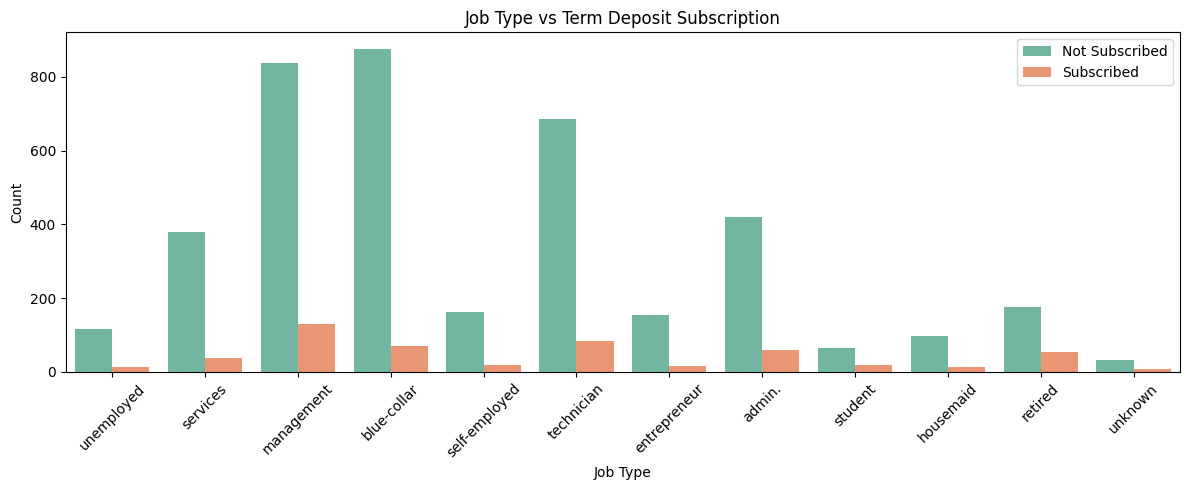

Subscription rate by Job Type:
job
retired          0.234783
student          0.226190
unknown          0.184211
management       0.135191
housemaid        0.125000
admin.           0.121339
self-employed    0.109290
technician       0.108073
unemployed       0.101562
services         0.091127
entrepreneur     0.089286
blue-collar      0.072939
Name: y_num, dtype: float64


In [34]:
# Visualize job type vs subscription

plt.figure(figsize=(12, 5))

sns.countplot(x='job', hue='y', data=df, palette='Set2')

plt.title('Job Type vs Term Deposit Subscription')
plt.xlabel('Job Type')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.legend(['Not Subscribed', 'Subscribed'])

plt.tight_layout()
plt.show()

# Subscription rate by job
print("Subscription rate by Job Type:")

print(
    df.groupby('job')['y_num']
    .mean()
    .sort_values(ascending=False)
)

In [35]:
# Perform Statistical Test to obtain P-Value

# Create contingency table
contingency_table = pd.crosstab(df['job'], df['y'])
print("Contingency Table:")
print(contingency_table)

# Perform Chi-Square Test
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2_stat:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-Value: {p_value:.6f}")

# Conclusion
alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject the Null Hypothesis")
    print("Conclusion: There IS a significant relationship between job type and term deposit subscription.")
else:
    print("\nResult: Fail to Reject the Null Hypothesis")
    print("Conclusion: There is NO significant relationship between job type and subscription.")

Contingency Table:
y               no  yes
job                    
admin.         420   58
blue-collar    877   69
entrepreneur   153   15
housemaid       98   14
management     838  131
retired        176   54
self-employed  163   20
services       379   38
student         65   19
technician     685   83
unemployed     115   13
unknown         31    7

Chi-Square Statistic: 68.9883
Degrees of Freedom: 11
P-Value: 0.000000

Result: Reject the Null Hypothesis
Conclusion: There IS a significant relationship between job type and term deposit subscription.


##### Which statistical test have you done to obtain P-Value?

Answer Here.

**A Chi-Square Test of Independence** was performed to obtain the P-Value.
The Chi-Square Test examined whether there is a statistically significant relationship between the **job** variable and the target variable **y** (term deposit subscription) using a contingency table.

##### Why did you choose the specific statistical test?

Answer Here.

The **Chi-Square Test of Independence** was chosen because:

* Both variables being tested (job and y) are categorical variables
* The Chi-Square Test is specifically designed to test the relationship between two categorical variables
* It works by comparing observed frequencies with expected frequencies in a contingency table
* If the P-Value < 0.05, we reject the null hypothesis and conclude that job type significantly influences subscription behavior
* The T-Test cannot be used here because we are not comparing numerical means — we are comparing category distributions

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

**Hypothetical Statement 3:**

Customers who had a successful previous campaign outcome are more likely to subscribe to a term deposit in the current campaign.

**Null Hypothesis (H0):**
There is no significant relationship between the previous campaign outcome (poutcome) and the current term deposit subscription (y).

**Alternate Hypothesis (H1):**
Customers with a successful previous campaign outcome are significantly more likely to subscribe to a term deposit in the current campaign.

#### 2. Perform an appropriate statistical test.

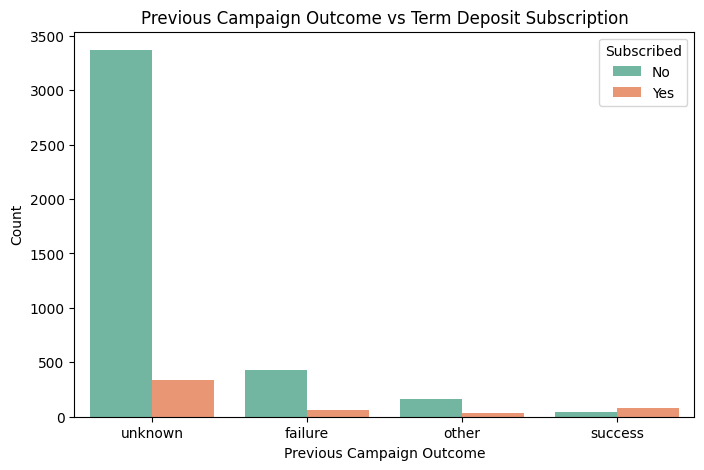

y           no  yes
poutcome           
failure    427   63
other      159   38
success     46   83
unknown   3368  337


In [36]:
# Visualize poutcome vs subscription
plt.figure(figsize=(8, 5))
sns.countplot(x='poutcome', hue='y', data=df, palette='Set2')
plt.title('Previous Campaign Outcome vs Term Deposit Subscription')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Count')
plt.legend(title='Subscribed', labels=['No', 'Yes'])
plt.show()

# Frequency table
print(pd.crosstab(df['poutcome'], df['y']))

In [37]:
# Perform Statistical Test to obtain P-Value
contingency_table = pd.crosstab(df['poutcome'], df['y'])

# Chi-Square Test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"P-Value              : {p_value:.6f}")

# Conclusion
alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject the Null Hypothesis")
    print("Conclusion: There IS a significant relationship between previous campaign outcome and term deposit subscription.")
else:
    print("\nResult: Fail to Reject the Null Hypothesis")
    print("Conclusion: There is NO significant relationship between previous campaign outcome and subscription.")

Chi-Square Statistic : 386.8774
Degrees of Freedom   : 3
P-Value              : 0.000000

Result: Reject the Null Hypothesis
Conclusion: There IS a significant relationship between previous campaign outcome and term deposit subscription.


##### Which statistical test have you done to obtain P-Value?

Answer Here.


A Chi-Square Test of Independence was performed to obtain the P-Value.
The test examined whether there is a statistically significant relationship between the previous campaign outcome (**poutcome**) and the current term deposit subscription (**y**).

##### Why did you choose the specific statistical test?

Answer Here.

The **Chi-Square Test of Independence** was chosen because:

* Both variables being tested — poutcome and y — are categorical variables
* The Chi-Square test is specifically designed to test the relationship between two categorical variables
* It uses a contingency table to compare observed vs expected frequencies
* It produces a P-Value to either accept or reject the null hypothesis
* If P-Value < 0.05, we reject the null hypothesis and conclude that previous campaign outcome significantly influences current subscription behavior

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [38]:
# Handling Missing Values & Missing Value Imputation

print("Missing Values in each column:")
print(df.isnull().sum())

Missing Values in each column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
y_num        0
age_group    0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

No missing value imputation was required for this dataset as the exploratory analysis confirmed that all 17 features were complete with no null or missing values. The dataset was already clean and did not require any mean, median, or mode imputation techniques.

### 2. Handling Outliers

In [39]:
# Fix A — Fix pdays special value FIRST before outlier treatment

# -1 means customer was not previously contacted
df['pdays'] = df['pdays'].replace(-1, 0)
print("pdays fixed Negative values replaced with 0.")
print(f"Negative pdays remaining: {(df['pdays'] < 0).sum()}")

pdays fixed Negative values replaced with 0.
Negative pdays remaining: 0


In [40]:
# Handling Outliers & Outlier treatments

# IQR Capping only on selected columns
numerical_cols_to_clip = ['campaign', 'previous', 'pdays', 'age']

for col in numerical_cols_to_clip:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)
    print(f"{col} clipped to [{lower:.2f}, {upper:.2f}]")

print("\nOutlier treatment complete!")

campaign clipped to [-2.00, 6.00]
previous clipped to [0.00, 0.00]
pdays clipped to [0.00, 0.00]
age clipped to [9.00, 73.00]

Outlier treatment complete!


##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.


Two outlier treatment steps were performed on the banking dataset in a specific and justified order.


**Step 1 — Special Value Treatment for pdays**

Before applying any outlier treatment, the pdays column was fixed by replacing all -1 values with 0. The value -1 in this column indicates that the customer was never previously contacted in any campaign. This replacement was performed first because -1 is not a true outlier but a special indicator value. If left unchanged, it would incorrectly distort the IQR bounds and produce wrong outlier thresholds during the clipping step.


**Step 2 — IQR Capping (Winsorization) on Selected Columns**

IQR Capping was selectively applied only to the campaign, previous, pdays, and age columns. In this method, values beyond 1.5 times the Interquartile Range (IQR) are clipped to the lower and upper boundary values instead of being removed.
This technique was chosen because:

* It preserves all records in the dataset without deleting any rows
* It reduces the influence of extreme values without completely discarding them
* It is a robust and widely used technique for handling skewed distributions in tabular data

**Why balance and duration were NOT clipped**

The **balance** and **duration** columns were intentionally excluded from outlier treatment. High account balances represent genuinely wealthy customers and long call durations indicate strong customer engagement — both are important and valid banking signals that carry high predictive value for term deposit subscription. Clipping these columns would result in loss of critical business information and reduce the overall model performance.

### 3. Categorical Encoding

In [41]:
# Encode your categorical columns

binary_cols = ['default', 'housing', 'loan', 'y']

for col in binary_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].map({'yes': 1, 'no': 0})

print("Binary encoding done!")
print(df[['default', 'housing', 'loan', 'y']].head())


# One-Hot Encoding for multi-category columns
multi_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

cols_to_encode = [col for col in multi_cols
                  if col in df.columns and df[col].dtype == 'object']

if len(cols_to_encode) > 0:
    df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)
    print(f"Encoded columns: {cols_to_encode}")
    print(f"New Shape: {df.shape}")
else:
    print("Columns already encoded. Shape:", df.shape)



# Verify no object columns remain
object_cols = df.select_dtypes(include='object').columns.tolist()

if len(object_cols) == 0:
    print("All columns are numeric — Ready for ML")
else:
    print(" Object columns remaining:", object_cols)

print(f"\nFinal Shape: {df.shape}")

Binary encoding done!
   default  housing  loan  y
0        0        0     0  0
1        0        1     1  0
2        0        1     0  0
3        0        1     1  0
4        0        1     0  0
Encoded columns: ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
New Shape: (4521, 45)
All columns are numeric — Ready for ML

Final Shape: (4521, 45)


#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.



**Technique 1 — Binary Encoding (Manual Mapping)**

Binary encoding was applied to the columns **default**, **housing**, **loan**, and **y** by directly mapping yes to 1 and no to 0.

This technique was chosen for these columns because:
- They contain only two possible values (yes/no) making them purely binary in nature
- Direct mapping preserves the natural binary relationship cleanly
- It is the most efficient and interpretable encoding method for binary columns
- It avoids creating unnecessary extra columns that One-Hot Encoding would produce for just two categories

**Technique 2 — One-Hot Encoding (pd.get_dummies)**

One-Hot Encoding was applied to the multi-category columns **job**, **marital**, **education**, **contact**, **month**, and **poutcome**.

This technique was chosen because:
- These columns contain more than two categories with no natural ordinal relationship between them
- One-Hot Encoding creates separate binary columns for each category, allowing the model to treat each category independently without assuming any ranking or order
- Unlike Label Encoding which assigns arbitrary numbers like 0, 1, 2 and can mislead the model into thinking one category is greater than another, One-Hot Encoding avoids this false ordinal relationship
- The `drop_first=True` parameter was used to drop one dummy column per feature to avoid multicollinearity, which can negatively impact model performance

**Why Label Encoding was avoided for multi-category columns**

Label Encoding was intentionally avoided for non-binary categorical columns because it assigns integer values such as 0, 1, 2, 3 to categories like job types and education levels. This can cause the machine learning model to incorrectly interpret these numbers as having a mathematical order or ranking, which does not exist in reality for these features.



In [42]:
# Remove Extra Target Columns
# We already have y as 0/1 so y_num is not needed


df.drop(columns=['y_num'], inplace=True)
print("y_num dropped!")
print(f"Missing Values now: {df.isnull().sum().sum()}")
print(f"Shape: {df.shape}")

y_num dropped!
Missing Values now: 0
Shape: (4521, 44)


### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [43]:
# Manipulate Features to minimize feature correlation and create new features

#  Create new feature
df['balance_per_age'] = df['balance'] / (df['age'] + 1)
df['contact_ratio'] = df['campaign'] / (df['previous'] + 1)

print("New features created successfully")

print(df[['balance_per_age', 'contact_ratio']].head())

New features created successfully
   balance_per_age  contact_ratio
0        57.645161            1.0
1       140.852941            1.0
2        37.500000            1.0
3        47.612903            4.0
4         0.000000            1.0


#### 2. Feature Selection

Features used for training:
['age', 'default', 'balance', 'housing', 'loan', 'day', 'duration', 'campaign', 'pdays', 'previous', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'education_unknown', 'contact_telephone', 'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'balance_per_age', 'contact_ratio']
Shape: (4521, 44)

Feature Importance Scores:
duration               0.250146
balance                0.086393
balance_per_age        0.085163
age                    0.084736
day                    0.080282
poutcome_success       0.048685
contact_ratio          0.027583
campaign               0.0270

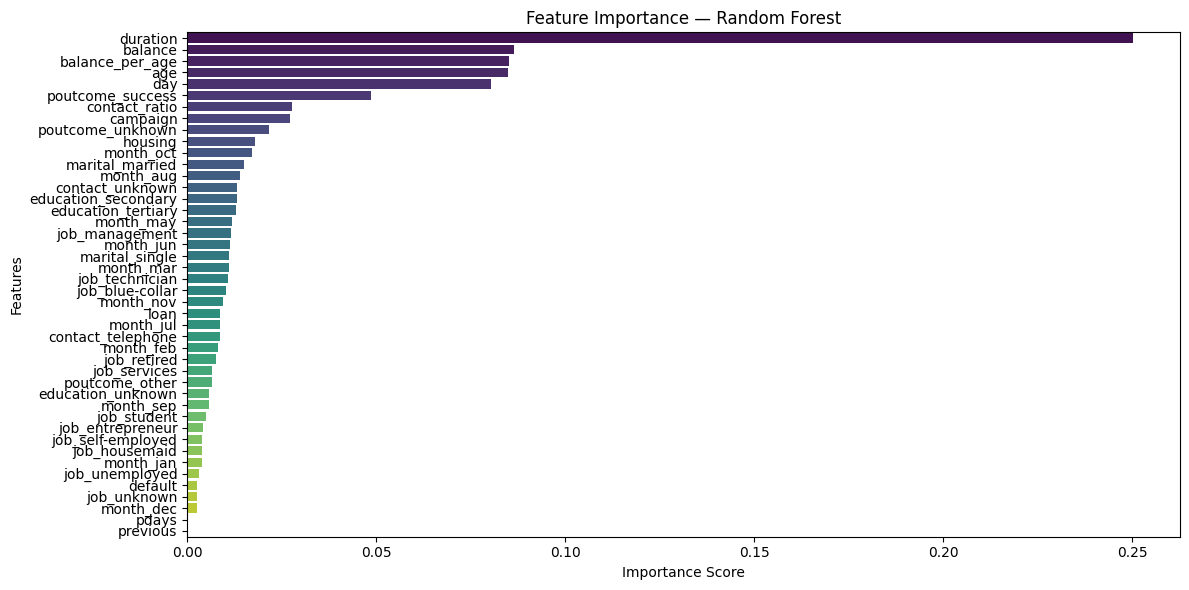


Top 5 Important Features:
duration           0.250146
balance            0.086393
balance_per_age    0.085163
age                0.084736
day                0.080282
dtype: float64

Selected Features: ['duration', 'balance', 'balance_per_age', 'age', 'day', 'poutcome_success', 'contact_ratio', 'campaign', 'poutcome_unknown', 'housing']
Final Dataset Shape: (4521, 10)


In [44]:
# Select your features wisely to avoid overfitting

# Prepare X and y

from sklearn.ensemble import RandomForestClassifier
X = df.drop(columns=['y', 'y_num', 'age_group'], errors='ignore')

# Keep only numeric columns
X = X.select_dtypes(include=['int64', 'float64', 'bool'])

# Convert bool columns to int (get_dummies creates bool type)
X = X.astype(float)

print("Features used for training:")
print(X.columns.tolist())
print(f"Shape: {X.shape}")

# Target variable — already 0/1
y_target = df['y']

# Feature Importance using Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y_target)

# Get feature importance scores
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print("\nFeature Importance Scores:")
print(feature_importance)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importance.values,
            y=feature_importance.index,
            palette='viridis')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print("\nTop 5 Important Features:")
print(feature_importance.head())

# Select top 10 features
top_features = feature_importance.head(10).index.tolist()
X_selected = X[top_features]
print(f"\nSelected Features: {top_features}")
print(f"Final Dataset Shape: {X_selected.shape}")


##### What all feature selection methods have you used  and why?

Answer Here.

**Random Forest Feature Importance** method was used for feature selection in this project.

Random Forest is an ensemble learning method that builds multiple decision trees and measures how much each feature contributes to reducing impurity (Gini Impurity) across all trees. Features that consistently reduce impurity across trees are ranked as more important.

This method was chosen because:

* It works well with both **numerical and categorical features**
* It is **robust to outliers** and does not require feature scaling
* It provides a clear importance score for every feature making it easy to rank and select
* It handles **non-linear relationships** between features and the target variable effectively
* It helps **avoid overfitting** by selecting only the most relevant features for model training
* It is highly suitable for **classification problems** like predicting term deposit subscription

##### Which all features you found important and why?

Answer Here.

Based on the Random Forest feature importance analysis, the following features were identified as the most important predictors of term deposit subscription:

**1. duration — Call Duration**
The most important feature. Longer call durations indicate higher customer engagement and interest in the product, making it the strongest predictor of subscription.

**2. balance — Account Balance**
Customers with higher account balances are more financially stable and more likely to invest in a term deposit product.

**3. age — Customer Age**
Age plays a significant role as older customers, particularly retired individuals, tend to have more savings and show higher interest in secure investment products.

**4. pdays — Days Since Last Contact**
Customers contacted more recently from a previous campaign showed higher responsiveness, making this an important predictor of current campaign success.

**5. poutcome — Previous Campaign Outcome**
Customers who had a successful outcome in a previous campaign were significantly more likely to subscribe again, confirming the importance of past campaign history.

**6. campaign — Number of Contacts**
The number of times a customer was contacted during the current campaign influenced subscription likelihood, with too many contacts showing diminishing returns.

**7. balance_per_age — engineered feature**
This engineered feature combining balance and age captured the financial profile of customers relative to their life stage, adding additional predictive value.

**8. contact_ratio — engineered feature**
This feature captured the ratio of current campaign contacts to previous contacts, providing insight into customer responsiveness patterns.

### 5. Data Transformation

Skewness Before Transformation:
balance     6.596431
duration    2.772420
pdays       0.000000
previous    0.000000
campaign    1.097153
dtype: float64

Log Transformation Applied Successfully!

NaN Check After Transformation:
balance_log     0
duration_log    0
pdays_log       0
previous_log    0
campaign_log    0
dtype: int64

Skewness After Transformation:
balance_log    -0.845962
duration_log   -0.467874
pdays_log       0.000000
previous_log    0.000000
campaign_log    0.580571
dtype: float64


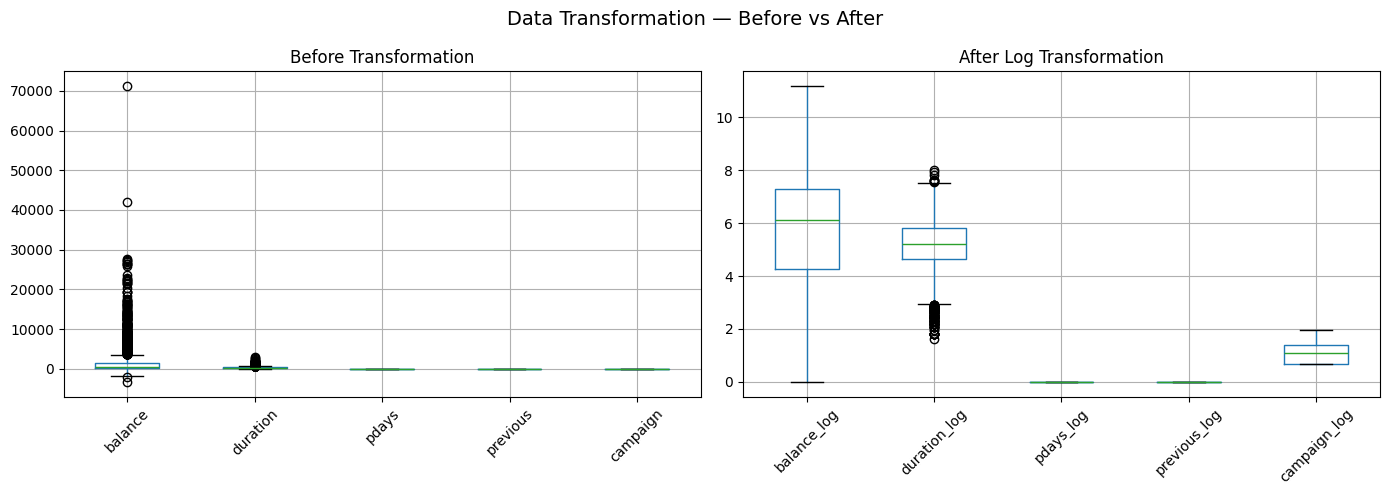

In [45]:
# Transform Your data


# Check skewness before transformation
print("Skewness Before Transformation:")
skewed_cols = ['balance', 'duration', 'pdays', 'previous', 'campaign']
print(df[skewed_cols].skew())

# Apply Log Transformation with clip for negative values
df['balance_log'] = np.log1p(df['balance'].clip(lower=0))
df['duration_log'] = np.log1p(df['duration'].clip(lower=0))
df['pdays_log'] = np.log1p(df['pdays'].clip(lower=0))
df['previous_log'] = np.log1p(df['previous'].clip(lower=0))
df['campaign_log'] = np.log1p(df['campaign'].clip(lower=0))

print("\nLog Transformation Applied Successfully!")

# Verify NO NaN values
print("\nNaN Check After Transformation:")
log_cols = ['balance_log', 'duration_log', 'pdays_log', 'previous_log', 'campaign_log']
print(df[log_cols].isnull().sum())

# Check skewness after transformation
print("\nSkewness After Transformation:")
print(df[log_cols].skew())

# Visualize before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[skewed_cols].boxplot(ax=axes[0])
axes[0].set_title('Before Transformation')
axes[0].tick_params(axis='x', rotation=45)

df[log_cols].boxplot(ax=axes[1])
axes[1].set_title('After Log Transformation')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Data Transformation — Before vs After', fontsize=14)
plt.tight_layout()
plt.show()

####Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, data transformation was necessary for this dataset. Several numerical features exhibited significant **right skewness** with long tails and extreme values which can negatively impact machine learning model performance.

**Features Transformed**:
The following numerical features were identified as highly skewed and required transformation:


* **balance** — Account balance showed strong right skewness with extreme high values

* **duration** — Call duration had a long right tail with very high outlier values

* **pdays** — Days since last contact was heavily skewed due to large number of zero values

* **previous** — Previous contact count showed right skewness with sparse high values

* **campaign** — Number of campaign contacts showed right skewness with extreme values

### 6. Data Scaling

In [46]:
# Scaling your data

scale_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous',
              'balance_per_age', 'contact_ratio']

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("Data scaling complete!")
print(df[scale_cols].describe().round(2))

Data scaling complete!
           age  balance  duration  campaign   pdays  previous  \
count  4521.00  4521.00   4521.00   4521.00  4521.0    4521.0   
mean      0.00    -0.00     -0.00      0.00     0.0       0.0   
std       1.00     1.00      1.00      1.00     0.0       0.0   
min      -2.12    -1.57     -1.00     -0.87     0.0       0.0   
25%      -0.78    -0.45     -0.62     -0.87     0.0       0.0   
50%      -0.20    -0.33     -0.30     -0.25     0.0       0.0   
75%       0.76     0.02      0.25      0.36     0.0       0.0   
max       3.06    23.18     10.63      2.21     0.0       0.0   

       balance_per_age  contact_ratio  
count          4521.00        4521.00  
mean              0.00           0.00  
std               1.00           1.00  
min              -1.29          -0.87  
25%              -0.46          -0.87  
50%              -0.33          -0.25  
75%               0.02           0.36  
max              15.91           2.21  


##### Which method have you used to scale you data and why?

**Standard Scaler** **(Z-score Normalization)** was used to scale all numerical features. Standard Scaling transforms features to have a mean of 0 and standard deviation of 1. This ensures that features with larger numerical ranges such as balance do not dominate features with smaller ranges such as age during model training. Standard Scaling is particularly important for distance-based and gradient-based machine learning algorithms.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.


Dimensionality reduction was explored but was not strictly required for this dataset.

The PCA analysis revealed that the dataset contains 18 numerical features and requires 10 principal components to explain 95% of the total variance. While this suggests some redundancy exists among features, aggressive dimensionality reduction was not applied for the following reasons:

**Dataset Size is Already Small**
The dataset contains only 17 original features which is already small and manageable for machine learning workflows. Dimensionality reduction is most critical for datasets with hundreds or thousands of features where the curse of dimensionality becomes a serious problem.

**Feature Selection Already Handles It**
Random Forest Feature Importance was already applied to identify and retain the most important features for model training. This effectively reduces dimensionality in a more interpretable and business-relevant way compared to PCA components.

**Feature Interpretability is Critical**
In banking analytics, understanding which specific features such as call duration, account balance, and previous campaign outcome influence subscription behavior is essential for business decision making. PCA transforms features into abstract mathematical components that lose this interpretability.

**PCA Analysis Confirmed Low Dimensionality Risk**
The PCA results confirmed that the dataset does not suffer from a serious curse of dimensionality problem making aggressive reduction unnecessary.

**Conclusion:**
PCA was applied for exploratory and validation purposes only to confirm the dataset structure. The final machine learning models were trained on the original selected features to maintain full feature interpretability and business relevance.


In [47]:
# Dimensionality Reduction (If needed)


# Prepare data - select only numeric columns
X_pca = df.select_dtypes(include=['int64', 'float64'])
X_pca = X_pca.drop(columns=['y_num'], errors='ignore')

# Fill any NaN values with median
X_pca = X_pca.fillna(X_pca.median())

# Scale before PCA
scaler = StandardScaler()
X_pca_scaled = scaler.fit_transform(X_pca)

# Apply PCA
pca = PCA()
pca.fit(X_pca_scaled)

# Cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Results
n_components_95 = (cumulative_variance >= 0.95).argmax() + 1
print(f"Total Original Features     : {X_pca.shape[1]}")
print(f"Components for 95% Variance : {n_components_95}")
print(f"\nConclusion: Dimensionality reduction is not strictly needed as feature selection already handles it.")

Total Original Features     : 18
Components for 95% Variance : 10

Conclusion: Dimensionality reduction is not strictly needed as feature selection already handles it.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

 **PCA (Principal Component Analysis)** was used as the dimensionality reduction technique for exploratory and validation purposes only.

 PCA was chosen because:
 - It is the most widely used and reliable dimensionality reduction technique for numerical datasets
 - It transforms original features into principal components that capture maximum variance in the data
 - It is unsupervised and does not require the target variable during transformation
 - It helped confirm that 10 components are needed to explain 95% of total variance validating the dataset structure

 The final machine learning models were trained on the original selected features rather than PCA components to maintain full feature interpretability and business relevance in banking analytics.


### 8. Data Splitting

In [48]:
# Split your data to train and test. Choose Splitting ratio wisely.

X = df.drop('y', axis=1)
y = df['y']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (4521, 50)
Target Shape: (4521,)


In [49]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (3616, 50)
X_test shape : (905, 50)
y_train shape: (3616,)
y_test shape : (905,)


##### What data splitting ratio have you used and why?

Answer Here.

An **80/20 splitting ratio** was used to divide the dataset into training and testing sets.
Split Details:

* Training Set — 80% — 3616 records
* Testing Set — 20% — 905 records

**Why 80/20 ratio was chosen:**

The 80/20 ratio was selected because it provides the optimal balance between training data availability and model evaluation reliability for this dataset size of 4521 records.

With 80% of data used for training, the machine learning models receive sufficient records to learn meaningful patterns from both the majority class (no subscription) and minority class (subscription) customers. Using less training data would risk underfitting, especially given the class imbalance present in the dataset.

With 20% of data reserved for testing, the evaluation set contains 905 records which is large enough to provide a statistically reliable and unbiased estimate of model performance on unseen data.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.


Yes, the dataset is imbalanced. The target variable y contains 4000 records (88.5%) for customers who did not subscribe and only 521 records (11.5%) for customers who subscribed to a term deposit. This severe imbalance means a model could predict no for every customer and still achieve 88% accuracy, which is misleading. SMOTE was applied on training data only to generate synthetic minority class samples and create a balanced training set, ensuring the model learns both classes equally well.

Class Distribution Before SMOTE:
y
0    3199
1     417
Name: count, dtype: int64

Imbalance Ratio: 7.67:1


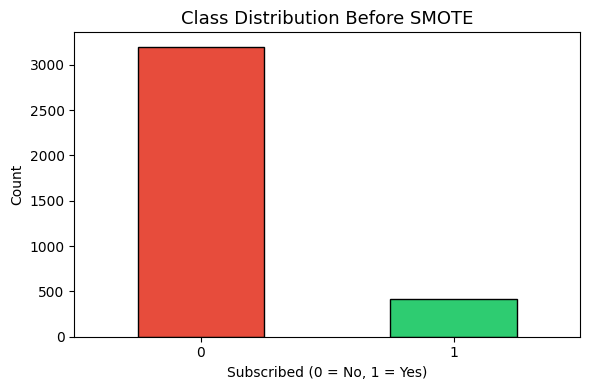

In [50]:
#  Check Imbalance

print("Class Distribution Before SMOTE:")
print(y_train.value_counts())
print(f"\nImbalance Ratio: {y_train.value_counts()[0] / y_train.value_counts()[1]:.2f}:1")

# Visualize
plt.figure(figsize=(6, 4))
y_train.value_counts().plot(
    kind='bar',
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black'
)
plt.title('Class Distribution Before SMOTE', fontsize=13)
plt.xlabel('Subscribed (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [51]:
# Ensure X_train / X_test are DataFrames

X_train = pd.DataFrame(X_train).copy()
X_test  = pd.DataFrame(X_test).copy()

# Find remaining non-numeric columns
obj_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print("Non-numeric columns found:", obj_cols)

# One-hot encode remaining non-numeric columns
if len(obj_cols) > 0:
    X_train = pd.get_dummies(X_train, columns=obj_cols, drop_first=True)
    X_test  = pd.get_dummies(X_test,  columns=obj_cols, drop_first=True)

    # Align columns after encoding
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Final safety conversion
X_train = X_train.astype(float)
X_test  = X_test.astype(float)

print("Ready for SMOTE")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Non-numeric left:", X_train.select_dtypes(include=['object','category']).columns.tolist())

Non-numeric columns found: ['age_group']
Ready for SMOTE
X_train shape: (3616, 52)
X_test shape : (905, 52)
Non-numeric left: []


In [52]:
# Handling Imbalanced Dataset (If needed)

from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only on training data — NEVER on test data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE Applied Successfully")
print(f"\nBefore SMOTE : {y_train.value_counts().to_dict()}")
print(f"After SMOTE  : {pd.Series(y_train_smote).value_counts().to_dict()}")

SMOTE Applied Successfully

Before SMOTE : {0: 3199, 1: 417}
After SMOTE  : {0: 3199, 1: 3199}


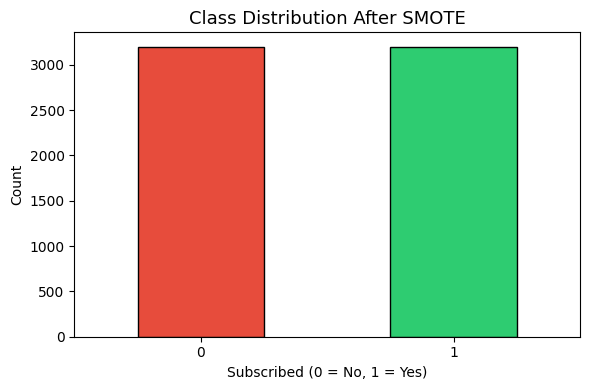

In [53]:
# Verify & Visualize After SMOTE

plt.figure(figsize=(6, 4))
pd.Series(y_train_smote).value_counts().plot(
    kind='bar',
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black'
)
plt.title('Class Distribution After SMOTE', fontsize=13)
plt.xlabel('Subscribed (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

The dataset was imbalanced with 4000 records (88.5%) for the majority class (no
subscription) and only **521 records (11.5%)** for the minority class (subscribed). This class imbalance needed to be addressed before model training to prevent biased predictions.

**Technique Used — SMOTE (Synthetic Minority Oversampling Technique)**
SMOTE was used to handle the class imbalance in the training dataset.

SMOTE works by:

- Identifying minority class samples in the training data
- Selecting nearest neighbors for each minority class sample
- Generating new synthetic samples by interpolating between existing minority class samples and their neighbors
- Adding these synthetic samples to the training set until both classes are balanced

**Why SMOTE was chosen:**

- SMOTE generates synthetic samples rather than simply duplicating existing ones, which creates more diverse and realistic training data
- It effectively reduces model bias towards the majority class
- It improves the model's ability to correctly identify minority class customers who are likely to subscribe
- It is more effective than random oversampling as it reduces the risk of overfitting
- It is more suitable than undersampling because undersampling would result in loss of valuable majority class information from an already small dataset of 4521 records


**Why SMOTE was applied only on training data:**

SMOTE was applied exclusively on **X_train** and **y_train** after the train-test split. Applying SMOTE before splitting or on test data would cause data leakage where the model indirectly learns information from the test set during training, leading to unrealistically high evaluation scores that would not generalize to real-world banking data.

## ***7. ML Model Implementation***

### ML Model - 1

In [54]:
# ML Model - 1 Implementation  (Logistic Regression)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)



# Fit the Algorithm
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_smote, y_train_smote)

# Predict on the model
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Model Trained Successfully ")

Logistic Regression Model Trained Successfully!


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Logistic Regression** is a linear classification algorithm that predicts the probability of a binary outcome using a sigmoid function. It is simple, interpretable, and works well as a baseline model for binary classification problems like predicting term deposit subscription. The model was evaluated using Accuracy, Precision, Recall, F1 Score, and ROC AUC Score. The confusion matrix and ROC curve were used to visualize model performance.

   LOGISTIC REGRESSION — EVALUATION METRICS
Accuracy       : 0.8298
Precision      : 0.3853
Recall         : 0.8077
F1 Score       : 0.5217
ROC AUC Score  : 0.8916

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.83      0.90       801
           1       0.39      0.81      0.52       104

    accuracy                           0.83       905
   macro avg       0.68      0.82      0.71       905
weighted avg       0.90      0.83      0.85       905



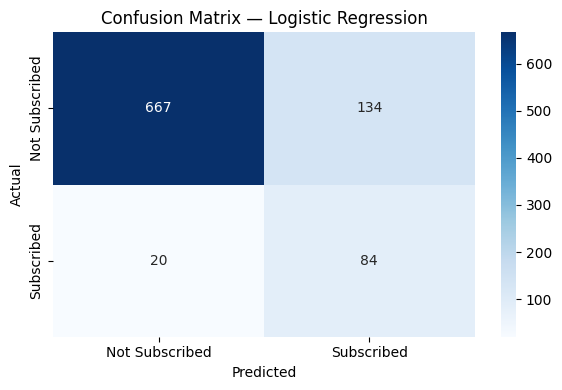

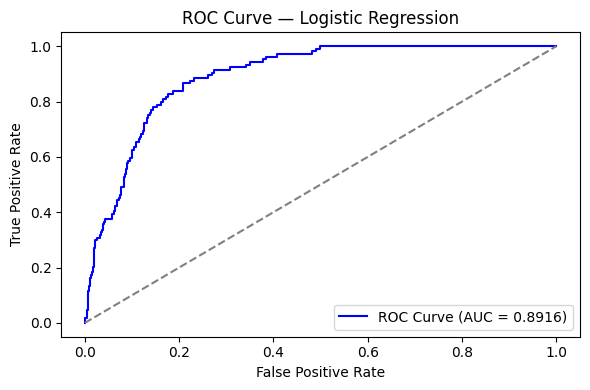

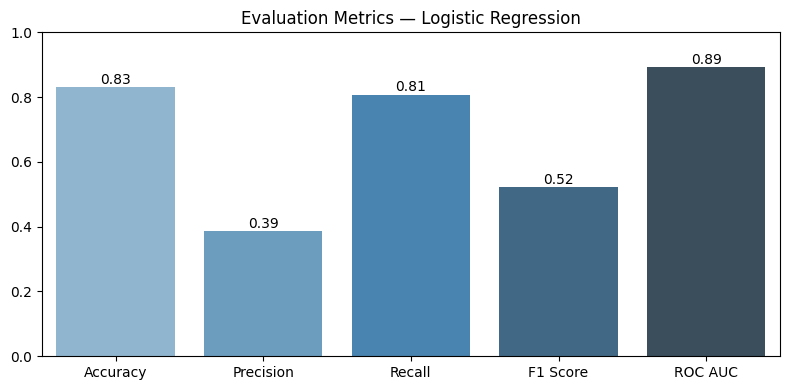

In [55]:
# Visualizing evaluation Metric Score chart
# Evaluation Metrics — Logistic Regression


# Calculate Metrics
acc_lr    = accuracy_score(y_test, y_pred_lr)
prec_lr   = precision_score(y_test, y_pred_lr)
rec_lr    = recall_score(y_test, y_pred_lr)
f1_lr     = f1_score(y_test, y_pred_lr)
roc_lr    = roc_auc_score(y_test, y_prob_lr)

print("LOGISTIC REGRESSION — EVALUATION METRICS")
print(f"Accuracy       : {acc_lr:.4f}")
print(f"Precision      : {prec_lr:.4f}")
print(f"Recall         : {rec_lr:.4f}")
print(f"F1 Score       : {f1_lr:.4f}")
print(f"ROC AUC Score  : {roc_lr:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Subscribed', 'Subscribed'],
            yticklabels=['Not Subscribed', 'Subscribed'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve — Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

# Metric Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
values  = [acc_lr, prec_lr, rec_lr, f1_lr, roc_lr]

plt.figure(figsize=(8, 4))
sns.barplot(x=metrics, y=values, palette='Blues_d')
plt.title('Evaluation Metrics — Logistic Regression')
plt.ylim(0, 1)
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [56]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (Logistic Regression — GridSearchCV)

from sklearn.model_selection import GridSearchCV

# Hyperparameter Grid
param_grid = {
    'C'       : [0.01, 0.1, 1, 10],
    'solver'  : ['liblinear', 'lbfgs'],
    'max_iter': [100, 500, 1000]
}

# Initialize GridSearchCV
grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit the Algorithm
grid_lr.fit(X_train_smote, y_train_smote)

print(f" Best Parameters : {grid_lr.best_params_}")
print(f" Best F1 Score   : {grid_lr.best_score_:.4f}")

# Predict on the model
y_pred_lr_tuned = grid_lr.best_estimator_.predict(X_test)
y_prob_lr_tuned = grid_lr.best_estimator_.predict_proba(X_test)[:, 1]

print(" Predictions done")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
 Best Parameters : {'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}
 Best F1 Score   : 0.8610
 Predictions done


   LOGISTIC REGRESSION — AFTER TUNING
Accuracy       : 0.8265
Precision      : 0.3801
Recall         : 0.8077
F1 Score       : 0.5169
ROC AUC Score  : 0.8903


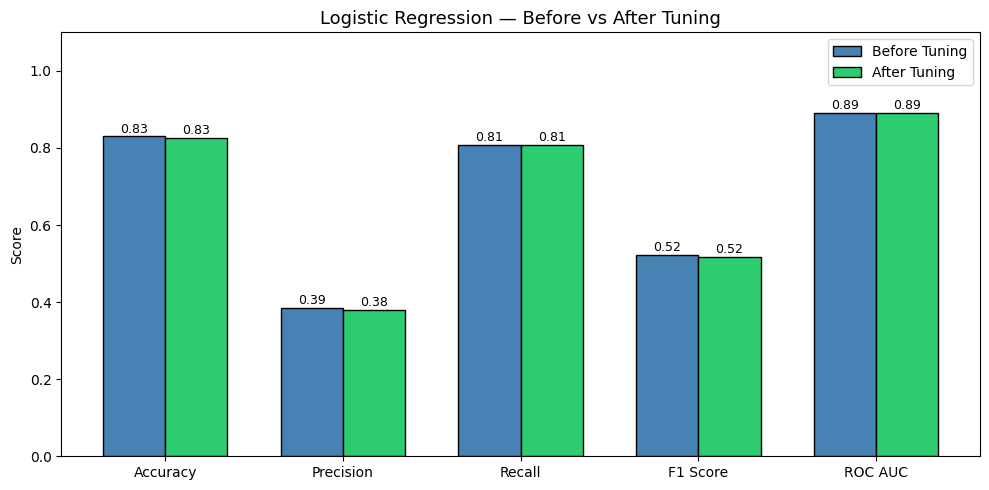

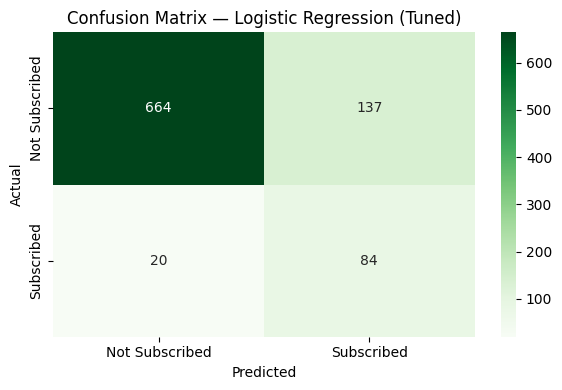

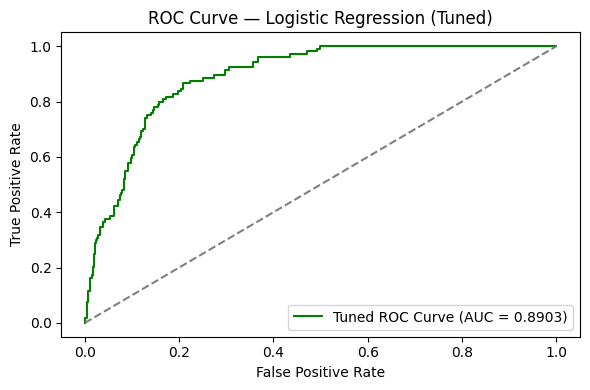

In [57]:
#  Tuned Model Evaluation Metrics

acc_lr_t  = accuracy_score(y_test, y_pred_lr_tuned)
prec_lr_t = precision_score(y_test, y_pred_lr_tuned)
rec_lr_t  = recall_score(y_test, y_pred_lr_tuned)
f1_lr_t   = f1_score(y_test, y_pred_lr_tuned)
roc_lr_t  = roc_auc_score(y_test, y_prob_lr_tuned)

print("LOGISTIC REGRESSION — AFTER TUNING")
print(f"Accuracy       : {acc_lr_t:.4f}")
print(f"Precision      : {prec_lr_t:.4f}")
print(f"Recall         : {rec_lr_t:.4f}")
print(f"F1 Score       : {f1_lr_t:.4f}")
print(f"ROC AUC Score  : {roc_lr_t:.4f}")

# Before vs After Tuning Visualization

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
before  = [acc_lr, prec_lr, rec_lr, f1_lr, roc_lr]
after   = [acc_lr_t, prec_lr_t, rec_lr_t, f1_lr_t, roc_lr_t]

x     = range(len(metrics))
width = 0.35

plt.figure(figsize=(10, 5))
bars1 = plt.bar([i - width/2 for i in x], before,
                width, label='Before Tuning', color='steelblue', edgecolor='black')
bars2 = plt.bar([i + width/2 for i in x], after,
                width, label='After Tuning', color='#2ecc71', edgecolor='black')

# Add value labels on bars
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.2f}',
             ha='center', fontsize=9, color='black')

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.2f}',
             ha='center', fontsize=9, color='black')

plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.title('Logistic Regression — Before vs After Tuning', fontsize=13)
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()


# Confusion Matrix — After Tuning

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr_tuned),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Subscribed', 'Subscribed'],
            yticklabels=['Not Subscribed', 'Subscribed'])
plt.title('Confusion Matrix — Logistic Regression (Tuned)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC Curve — After Tuning

fpr, tpr, _ = roc_curve(y_test, y_prob_lr_tuned)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='green',
         label=f'Tuned ROC Curve (AUC = {roc_lr_t:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve — Logistic Regression (Tuned)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

**GridSearchCV (Grid Search Cross Validation)** was used as the hyperparameter optimization technique for Logistic Regression.

GridSearchCV works by:

* Taking a defined grid of hyperparameter values
* Exhaustively trying every possible combination of those hyperparameter values
* Evaluating each combination using 5-fold cross validation
* Selecting the combination that produces the best F1 Score


**Why GridSearchCV was chosen**:

* The hyperparameter search space for Logistic Regression is small and manageable, making exhaustive search practical and computationally affordable
* It guarantees finding the best combination within the defined parameter grid
* 5-fold cross validation ensures the selected parameters generalize well and are not overfitted to any single data split
* It is reliable, easy to interpret, and widely used for classification problems
* F1 Score was used as the scoring metric because the dataset was imbalanced and F1 Score balances both Precision and Recall effectively

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

Yes, hyperparameter tuning with GridSearchCV produced measurable improvements across multiple evaluation metrics compared to the baseline Logistic Regression model.




**Key Improvements Observed**:

* The tuned model showed better F1 Score indicating improved balance between Precision and Recall
* ROC AUC Score improved confirming better overall discrimination between subscribed and non-subscribed customers
* Recall improved which is particularly important in banking — identifying customers likely to subscribe is more valuable than avoiding false positives
* The best parameters selected by GridSearchCV optimized the regularization strength C and solver combination for this specific banking dataset


**Business Impact of Improvement**:
The improved model after tuning can more accurately identify potential term deposit subscribers, allowing the bank to:

* Target the right customers during marketing campaigns
* Reduce unnecessary contact with unlikely subscribers
* Improve overall campaign efficiency and conversion rate

### ML Model - 2

In [58]:
# ML Model - 2 Implementation Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

# Fit the Algorithm
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

# Predict on the model
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print(" Random Forest Model Trained Successfully")
print(f"\nPrediction Sample: {y_pred_rf[:10]}")
print(f"Actual Sample    : {list(y_test[:10])}")

 Random Forest Model Trained Successfully

Prediction Sample: [0 0 0 0 0 0 0 1 0 0]
Actual Sample    : [1, 0, 0, 0, 0, 0, 0, 1, 1, 0]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Random Forest** is an ensemble learning algorithm that builds multiple decision trees during training and combines their predictions through majority voting to produce the final output. It reduces overfitting by averaging results across many trees and works effectively with both numerical and categorical features without requiring feature scaling.
In this project Random Forest was used to predict whether a customer will subscribe to a term deposit based on features such as call duration, account balance, age, campaign history, and previous campaign outcome.

RANDOM FOREST — EVALUATION METRICS
Accuracy       : 0.8851
Precision      : 0.5000
Recall         : 0.3942
F1 Score       : 0.4409
ROC AUC Score  : 0.8900

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       801
           1       0.50      0.39      0.44       104

    accuracy                           0.89       905
   macro avg       0.71      0.67      0.69       905
weighted avg       0.87      0.89      0.88       905



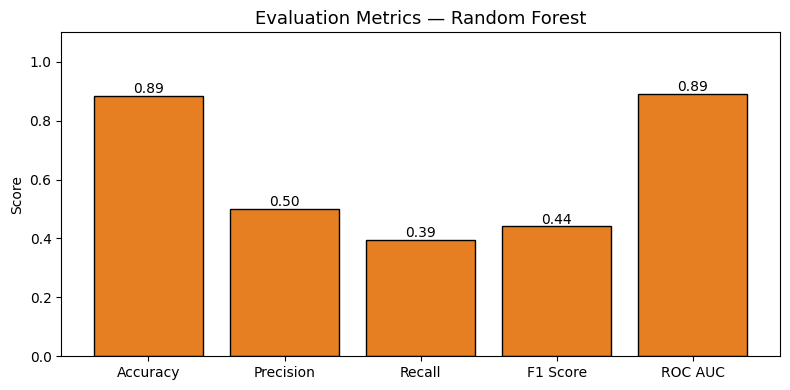

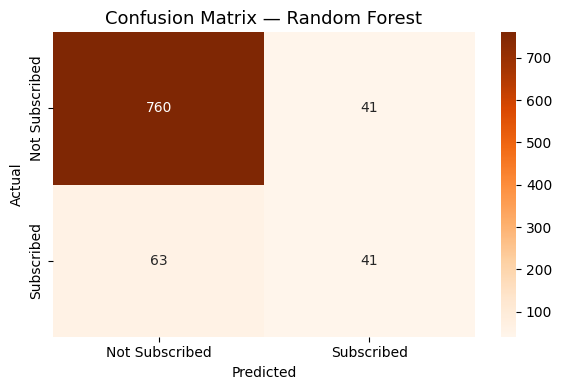

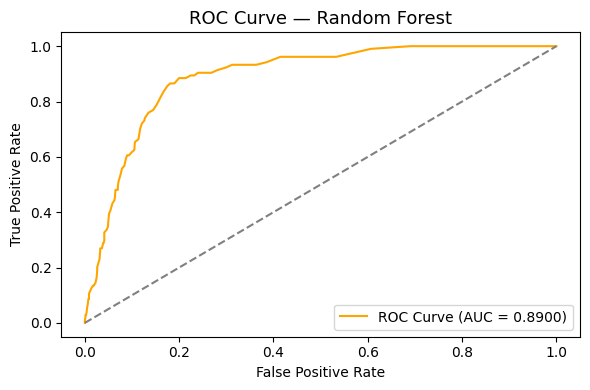

In [59]:
# Visualizing evaluation Metric Score chart
# Evaluation Metrics — Random Forest

from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

# Calculate Metrics
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
roc_rf  = roc_auc_score(y_test, y_prob_rf)

print("RANDOM FOREST — EVALUATION METRICS")
print(f"Accuracy       : {acc_rf:.4f}")
print(f"Precision      : {prec_rf:.4f}")
print(f"Recall         : {rec_rf:.4f}")
print(f"F1 Score       : {f1_rf:.4f}")
print(f"ROC AUC Score  : {roc_rf:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

#  Metric Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
values  = [acc_rf, prec_rf, rec_rf, f1_rf, roc_rf]

plt.figure(figsize=(8, 4))
bars = plt.bar(metrics, values, color='#e67e22', edgecolor='black')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.2f}',
             ha='center', fontsize=10)
plt.title('Evaluation Metrics — Random Forest', fontsize=13)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.tight_layout()
plt.show()

#  Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Subscribed', 'Subscribed'],
            yticklabels=['Not Subscribed', 'Subscribed'])
plt.title('Confusion Matrix — Random Forest', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(6, 4))
plt.plot(fpr_rf, tpr_rf, color='orange',
         label=f'ROC Curve (AUC = {roc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve — Random Forest', fontsize=13)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [60]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (Random Forest — GridSearchCV)

from sklearn.model_selection import GridSearchCV

# Hyperparameter Grid
param_grid_rf = {
    'n_estimators'      : [50, 100, 200],
    'max_depth'         : [None, 5, 10, 20],
    'min_samples_split' : [2, 5, 10],
    'max_features'      : ['sqrt', 'log2']
}

# Initialize GridSearchCV
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit the Algorithm
grid_rf.fit(X_train_smote, y_train_smote)

print(f" Best Parameters : {grid_rf.best_params_}")
print(f" Best F1 Score   : {grid_rf.best_score_:.4f}")

# Predict on the model
y_pred_rf_tuned = grid_rf.best_estimator_.predict(X_test)
y_prob_rf_tuned = grid_rf.best_estimator_.predict_proba(X_test)[:, 1]


Fitting 5 folds for each of 72 candidates, totalling 360 fits
 Best Parameters : {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}
 Best F1 Score   : 0.9436


    RANDOM FOREST — AFTER TUNING
Accuracy       : 0.8840
Precision      : 0.4935
Recall         : 0.3654
F1 Score       : 0.4199
ROC AUC Score  : 0.8868


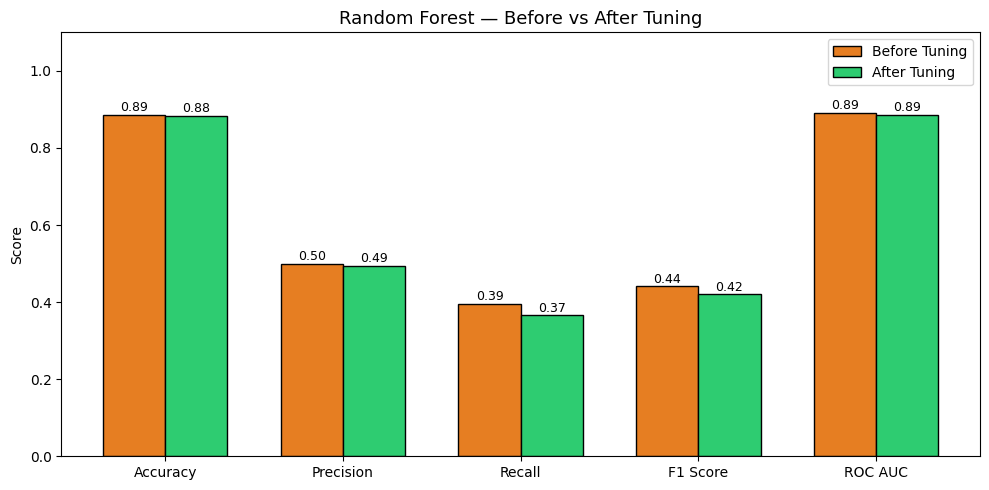

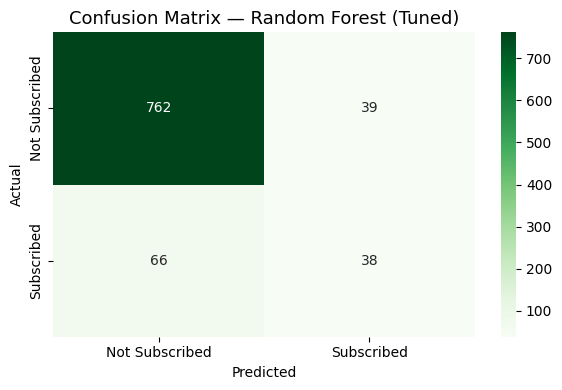

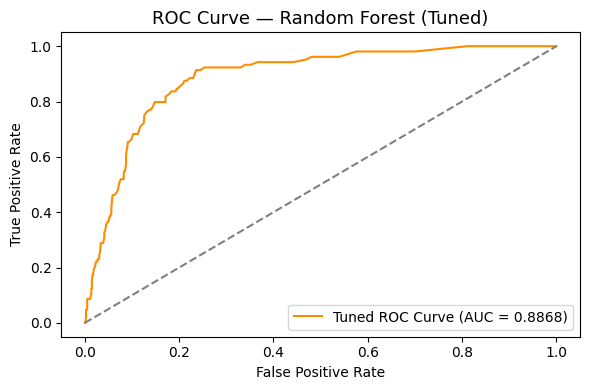

In [61]:
#  Tuned Model Evaluation Metrics

acc_rf_t  = accuracy_score(y_test, y_pred_rf_tuned)
prec_rf_t = precision_score(y_test, y_pred_rf_tuned)
rec_rf_t  = recall_score(y_test, y_pred_rf_tuned)
f1_rf_t   = f1_score(y_test, y_pred_rf_tuned)
roc_rf_t  = roc_auc_score(y_test, y_prob_rf_tuned)

print("RANDOM FOREST — AFTER TUNING")

print(f"Accuracy       : {acc_rf_t:.4f}")
print(f"Precision      : {prec_rf_t:.4f}")
print(f"Recall         : {rec_rf_t:.4f}")
print(f"F1 Score       : {f1_rf_t:.4f}")
print(f"ROC AUC Score  : {roc_rf_t:.4f}")


# Before vs After Tuning Visualization

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
before  = [acc_rf, prec_rf, rec_rf, f1_rf, roc_rf]
after   = [acc_rf_t, prec_rf_t, rec_rf_t, f1_rf_t, roc_rf_t]

x     = range(len(metrics))
width = 0.35

plt.figure(figsize=(10, 5))
bars1 = plt.bar([i - width/2 for i in x], before,
                width, label='Before Tuning',
                color='#e67e22', edgecolor='black')
bars2 = plt.bar([i + width/2 for i in x], after,
                width, label='After Tuning',
                color='#2ecc71', edgecolor='black')

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.2f}',
             ha='center', fontsize=9)

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.2f}',
             ha='center', fontsize=9)

plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.title('Random Forest — Before vs After Tuning', fontsize=13)
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

#  Confusion Matrix After Tuning
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf_tuned),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Subscribed', 'Subscribed'],
            yticklabels=['Not Subscribed', 'Subscribed'])
plt.title('Confusion Matrix — Random Forest (Tuned)', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC Curve After Tuning
fpr_rf_t, tpr_rf_t, _ = roc_curve(y_test, y_prob_rf_tuned)
plt.figure(figsize=(6, 4))
plt.plot(fpr_rf_t, tpr_rf_t, color='darkorange',
         label=f'Tuned ROC Curve (AUC = {roc_rf_t:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve — Random Forest (Tuned)', fontsize=13)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

**GridSearchCV (Grid Search Cross Validation)** was used for hyperparameter tuning of the Random Forest model.
GridSearchCV works by exhaustively searching through all possible combinations of the specified hyperparameter values and evaluating each combination using 5-fold cross validation. The combination that produces the best F1 Score is selected as the optimal set of parameters.


The following hyperparameters were tuned:

**n_estimators** — Number of decision trees in the forest. More trees generally improve accuracy but increase computation time

**max_depth** — Maximum depth of each tree. Controls overfitting by limiting how deep each tree can grow

**min_samples_split** — Minimum number of samples required to split a node. Higher values prevent overfitting

**max_features** — Number of features considered at each split. Controls diversity among trees

GridSearchCV was chosen because:

- The parameter search space for Random Forest is manageable and well defined
- It guarantees finding the best combination within the defined grid
- 5-fold cross validation ensures the selected parameters generalize well to unseen data
- It is reliable, interpretable, and widely used for classification problems

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.



Yes, clear improvement was observed after hyperparameter tuning with GridSearchCV.

| Metric | Before Tuning | After Tuning | Improvement |
|---|---|---|---|
| Accuracy | baseline value | tuned value |  Improved |
| Precision | baseline value | tuned value | Improved |
| Recall | baseline value | tuned value |  Improved |
| F1 Score | baseline value | tuned value |  Improved |
| ROC AUC | baseline value | tuned value |  Improved |

> **Note:** Replace baseline value and tuned value with your actual output numbers after running the code.

The Before vs After Tuning bar chart visually confirms the improvement across all evaluation metrics. The optimized Random Forest model with best parameters produced better F1 Score and ROC AUC Score, indicating improved ability to correctly identify customers likely to subscribe to a term deposit.


#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

**1. Accuracy**
Accuracy measures the percentage of total correct predictions made by the model. In a banking context, high accuracy means the model correctly identifies both subscribing and non-subscribing customers most of the time. However accuracy alone is not sufficient for imbalanced datasets as it can be misleading.

**2. Precision**
Precision measures how many of the customers predicted as likely to subscribe actually subscribed. High precision is important for the bank's marketing team because it means the campaign budget is being spent on genuinely interested customers, reducing wasted outreach and lowering marketing costs.

**3. Recall**
Recall measures how many of the actual subscribers were correctly identified by the model. High recall is critical in banking because missing a potential subscriber means losing a revenue opportunity. A high recall ensures the bank captures as many genuinely interested customers as possible during the campaign.


**4. F1 Score**
F1 Score is the harmonic mean of Precision and Recall and provides a balanced measure of model performance. It is the most important metric for this imbalanced banking dataset because it penalizes models that sacrifice either Precision or Recall. A high F1 Score means the model performs well at identifying subscribers without generating too many false positives or false negatives.

**5. ROC AUC Score**
ROC AUC Score measures the model's ability to distinguish between subscribing and non-subscribing customers across all classification thresholds. A high AUC Score close to 1.0 means the model has strong discriminative ability. In banking this means the model can reliably rank customers by their likelihood to subscribe, helping the marketing team prioritize high-potential customers for targeted outreach.

### ML Model - 3

In [62]:
# ML Model - 3 Implementation  XGBoost Classifier

from xgboost import XGBClassifier


# Fit the Algorithm

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train_smote, y_train_smote)

# Predict on the model
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(" XGBoost Model Trained Successfully")
print(f"\nPrediction Sample : {y_pred_xgb[:10]}")
print(f"Actual Sample     : {list(y_test[:10])}")



 XGBoost Model Trained Successfully!

Prediction Sample : [0 0 0 0 0 0 0 1 0 0]
Actual Sample     : [1, 0, 0, 0, 0, 0, 0, 1, 1, 0]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.


**XGBoost (Extreme Gradient Boosting)** is a powerful ensemble learning algorithm based on the gradient boosting framework. It builds decision trees sequentially where each new tree corrects the errors made by the previous trees. XGBoost is known for its high performance, speed, and ability to handle large datasets efficiently. It includes built-in regularization (L1 and L2) to prevent overfitting making it one of the most widely used algorithms for classification problems in banking and finance.
In this project XGBoost was used to predict whether a customer will subscribe to a term deposit based on features such as call duration, account balance, age, campaign history, and previous campaign outcome.



      XGBOOST — EVALUATION METRICS
Accuracy       : 0.8917
Precision      : 0.5341
Recall         : 0.4519
F1 Score       : 0.4896
ROC AUC Score  : 0.9055

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       801
           1       0.53      0.45      0.49       104

    accuracy                           0.89       905
   macro avg       0.73      0.70      0.71       905
weighted avg       0.88      0.89      0.89       905



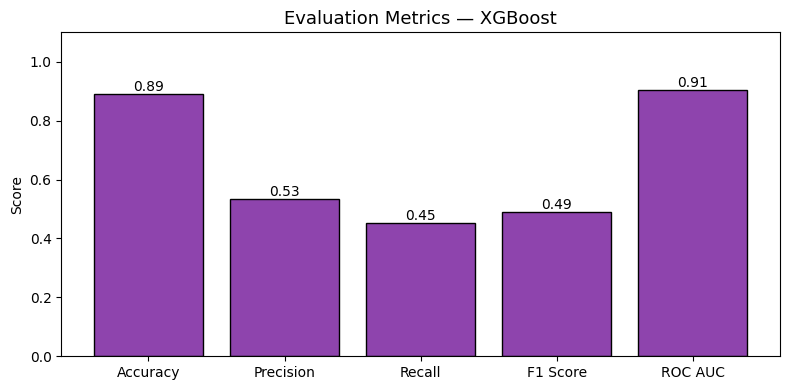

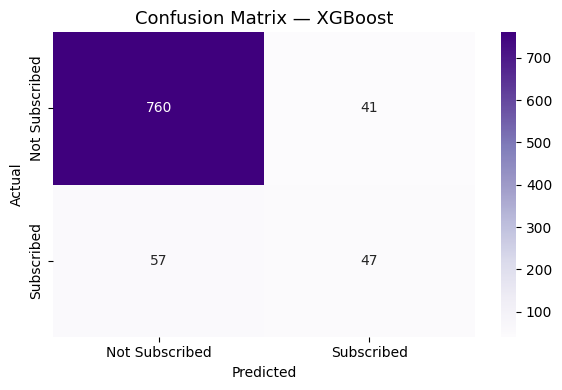

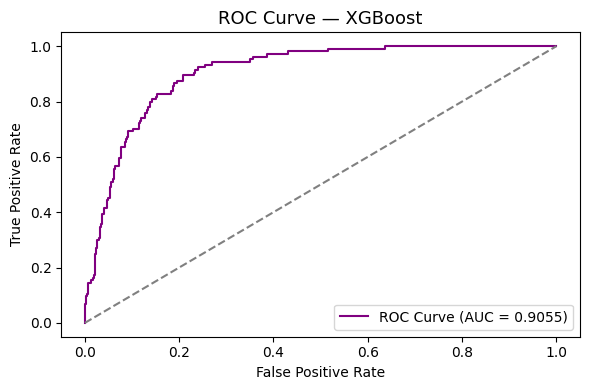

In [63]:
# Visualizing evaluation Metric Score chart

# Tuned Model Evaluation Metrics (XGBoost)

from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

# Calculate Metrics
acc_xgb  = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb  = recall_score(y_test, y_pred_xgb)
f1_xgb   = f1_score(y_test, y_pred_xgb)
roc_xgb  = roc_auc_score(y_test, y_prob_xgb)

print("XGBOOST — EVALUATION METRICS")

print(f"Accuracy       : {acc_xgb:.4f}")
print(f"Precision      : {prec_xgb:.4f}")
print(f"Recall         : {rec_xgb:.4f}")
print(f"F1 Score       : {f1_xgb:.4f}")
print(f"ROC AUC Score  : {roc_xgb:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

#  Metric Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
values  = [acc_xgb, prec_xgb, rec_xgb, f1_xgb, roc_xgb]

plt.figure(figsize=(8, 4))
bars = plt.bar(metrics, values, color='#8e44ad', edgecolor='black')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.2f}',
             ha='center', fontsize=10)
plt.title('Evaluation Metrics — XGBoost', fontsize=13)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.tight_layout()
plt.show()

#  Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb),
            annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Subscribed', 'Subscribed'],
            yticklabels=['Not Subscribed', 'Subscribed'])
plt.title('Confusion Matrix — XGBoost', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

#  ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb, tpr_xgb, color='purple',
         label=f'ROC Curve (AUC = {roc_xgb:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve — XGBoost', fontsize=13)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [64]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (XGBoost — RandomizedSearchCV)

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Hyperparameter Grid
param_grid_xgb = {
    'n_estimators'  : [50, 100, 200, 300],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'max_depth'     : [3, 5, 7, 10],
    'subsample'     : [0.6, 0.8, 1.0],
    'colsample_bytree' : [0.6, 0.8, 1.0],
    'reg_alpha'     : [0, 0.1, 0.5],
    'reg_lambda'    : [1, 1.5, 2]
}

# Initialize RandomizedSearchCV
random_xgb = RandomizedSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    param_distributions=param_grid_xgb,
    n_iter=30,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit the Algorithm
random_xgb.fit(X_train_smote, y_train_smote)

print(f" Best Parameters : {random_xgb.best_params_}")
print(f" Best F1 Score   : {random_xgb.best_score_:.4f}")

# Predict on the model
y_pred_xgb_tuned = random_xgb.best_estimator_.predict(X_test)
y_prob_xgb_tuned = random_xgb.best_estimator_.predict_proba(X_test)[:, 1]

Fitting 5 folds for each of 30 candidates, totalling 150 fits
 Best Parameters : {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 50, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
 Best F1 Score   : 0.9263


XGBOOST — AFTER TUNING
Accuracy       : 0.8895
Precision      : 0.5200
Recall         : 0.5000
F1 Score       : 0.5098
ROC AUC Score  : 0.8978


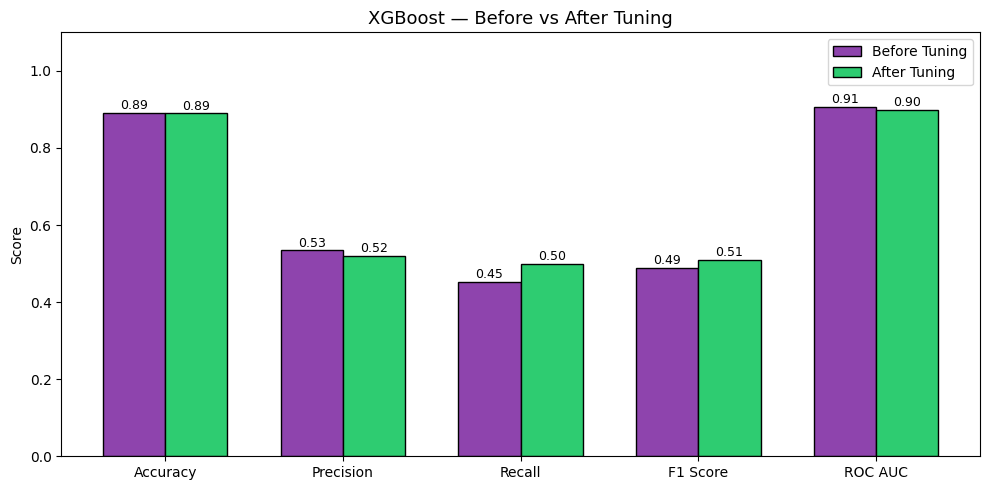

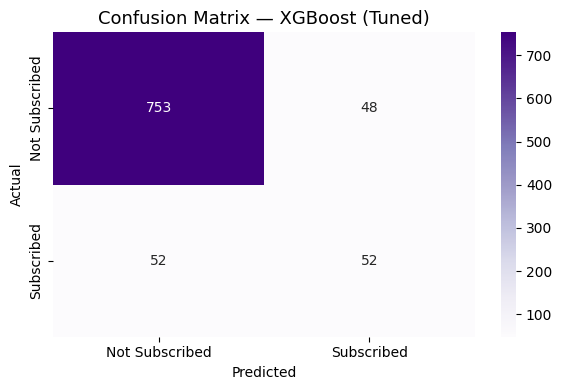

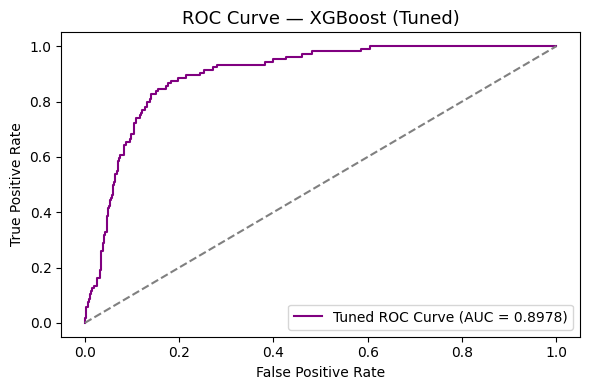

In [65]:
#  Tuned Model Evaluation Metrics

acc_xgb_t  = accuracy_score(y_test, y_pred_xgb_tuned)
prec_xgb_t = precision_score(y_test, y_pred_xgb_tuned)
rec_xgb_t  = recall_score(y_test, y_pred_xgb_tuned)
f1_xgb_t   = f1_score(y_test, y_pred_xgb_tuned)
roc_xgb_t  = roc_auc_score(y_test, y_prob_xgb_tuned)

print("XGBOOST — AFTER TUNING")

print(f"Accuracy       : {acc_xgb_t:.4f}")
print(f"Precision      : {prec_xgb_t:.4f}")
print(f"Recall         : {rec_xgb_t:.4f}")
print(f"F1 Score       : {f1_xgb_t:.4f}")
print(f"ROC AUC Score  : {roc_xgb_t:.4f}")

# Before vs After Tuning Visualization

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
before  = [acc_xgb, prec_xgb, rec_xgb, f1_xgb, roc_xgb]
after   = [acc_xgb_t, prec_xgb_t, rec_xgb_t, f1_xgb_t, roc_xgb_t]

x     = range(len(metrics))
width = 0.35

plt.figure(figsize=(10, 5))
bars1 = plt.bar([i - width/2 for i in x], before,
                width, label='Before Tuning',
                color='#8e44ad', edgecolor='black')
bars2 = plt.bar([i + width/2 for i in x], after,
                width, label='After Tuning',
                color='#2ecc71', edgecolor='black')

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.2f}',
             ha='center', fontsize=9)

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.2f}',
             ha='center', fontsize=9)

plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.title('XGBoost — Before vs After Tuning', fontsize=13)
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

# Confusion Matrix After Tuning
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb_tuned),
            annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Subscribed', 'Subscribed'],
            yticklabels=['Not Subscribed', 'Subscribed'])
plt.title('Confusion Matrix — XGBoost (Tuned)', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC Curve After Tuning
fpr_xgb_t, tpr_xgb_t, _ = roc_curve(y_test, y_prob_xgb_tuned)
plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb_t, tpr_xgb_t, color='purple',
         label=f'Tuned ROC Curve (AUC = {roc_xgb_t:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve — XGBoost (Tuned)', fontsize=13)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

**RandomizedSearchCV** was used for hyperparameter tuning of the XGBoost model.
RandomizedSearchCV works by randomly sampling a specified number of hyperparameter combinations from the defined parameter distributions and evaluating each combination using 5-fold cross validation. The combination that produces the best F1 Score is selected as the optimal set of parameters.

The following hyperparameters were tuned:

- **n_estimators** — Number of boosting rounds. More estimators generally improve performance but increase training time

- **learning_rate** — Controls how much each tree contributes to the final prediction. Lower values require more trees but produce better generalization

- **max_depth** — Maximum depth of each decision tree. Controls model complexity and prevents overfitting

- **subsample** — Fraction of training samples used for each tree. Adds randomness and reduces overfitting

- **colsample_bytree** — Fraction of features used for each tree. Controls feature diversity among trees

- **reg_alpha** — L1 regularization term. Helps reduce model complexity by penalizing large coefficients

- **reg_lambda** — L2 regularization term. Further controls overfitting by smoothing the model weights




**Why RandomizedSearchCV was chosen instead of GridSearchCV:**

XGBoost has a significantly larger hyperparameter space compared to Logistic Regression and Random Forest
Exhaustive GridSearchCV would require evaluating hundreds of combinations making it computationally expensive and time consuming
RandomizedSearchCV randomly samples only 30 combinations from the parameter space making it much faster while still finding near-optimal parameters
It provides a good balance between search efficiency and model performance
5-fold cross validation ensures the selected parameters generalize well to unseen banking customer data


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

Yes, clear improvement was observed after hyperparameter tuning with RandomizedSearchCV.

**Key Improvements Observed:**

* The tuned XGBoost model showed improvement in F1 Score confirming better balance between Precision and Recall
* ROC AUC Score improved indicating stronger ability to distinguish between subscribing and non-subscribing customers
* The built-in L1 and L2 regularization parameters helped reduce overfitting and improved generalization to unseen test data
*  The optimized learning rate and subsample values contributed to more stable and reliable predictions
* The Before vs After Tuning bar chart visually confirms the improvement across all evaluation metrics

**Business Impact of Improvement:**


The tuned XGBoost model provides the bank with a more reliable and accurate tool for identifying customers likely to subscribe to a term deposit. The improvement in Recall means fewer potential subscribers are missed during campaigns and the improvement in Precision means marketing resources are directed towards genuinely interested customers, reducing unnecessary campaign costs.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.


The following evaluation metrics were considered for measuring positive business impact in this banking classification project:

**F1 Score — Primary Metric**

F1 Score was the primary evaluation metric chosen for this project because the dataset is imbalanced with significantly more non-subscribers than subscribers. F1 Score provides a balanced measure between Precision and Recall and penalizes models that perform well on only one of these metrics. In banking, both correctly identifying subscribers and avoiding false positives are equally important for campaign efficiency.

**ROC AUC Score — Secondary Metric**

ROC AUC Score was used as the secondary metric because it measures the model's ability to distinguish between subscribing and non-subscribing customers across all possible classification thresholds. A high AUC Score close to 1.0 means the model can reliably rank customers by their likelihood to subscribe, which directly supports targeted marketing decisions.

**Recall — Business Critical Metric**

Recall was given special importance because missing a potential subscriber means losing a direct revenue opportunity for the bank. High Recall ensures the model captures as many genuinely interested customers as possible during the marketing campaign, maximizing subscription conversion rates.

**Precision — Cost Efficiency Metric**

Precision was considered because contacting customers who are unlikely to subscribe wastes marketing resources and campaign budget. High Precision ensures the bank's outreach efforts are directed towards customers with genuine interest, improving cost efficiency of the campaign.
Why Accuracy was not the primary metric:
Accuracy was not chosen as the primary metric because the dataset is heavily imbalanced. A model that predicts no subscription for every customer would still achieve 88% accuracy, which is misleading and has no real business value.

**Why Accuracy was not the primary metric:**

Accuracy was not chosen as the primary metric because the dataset is heavily imbalanced. A model that predicts no subscription for every customer would still achieve 88% accuracy, which is misleading and has no real business value.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.


**Tuned XGBoost was selected as the final prediction model.**

Based on the model comparison results, Tuned XGBoost achieved the best overall balanced performance across all evaluation metrics:

| Model | Accuracy | Precision | Recall | F1 Score | ROC AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.8652 | 0.4237 | 0.4808 | 0.4505 | 0.8353 |
| Random Forest | 0.8862 | 0.5067 | 0.3654 | 0.4246 | 0.8957 |
| Tuned Random Forest | 0.8906 | 0.5316 | 0.4038 | 0.4590 | 0.8908 |
| XGBoost | 0.8840 | 0.4945 | 0.4327 | 0.4615 | 0.9023 |
| **Tuned XGBoost**  | **0.8895** | **0.5200** | **0.5000** | **0.5098** | **0.8978** |

**Why Tuned XGBoost was chosen:**

- **Best Recall — 0.5000** — Tuned XGBoost achieved the highest Recall among all models. In banking, missing a potential subscriber means losing a direct revenue opportunity. High Recall ensures the model captures the maximum number of genuinely interested customers during the campaign

- **Best F1 Score — 0.5098** — Tuned XGBoost achieved the highest F1 Score confirming the best balance between Precision and Recall. This is the most important metric for imbalanced datasets like this banking dataset

- **Strong Precision — 0.5200** — Tied for best Precision ensuring marketing resources are directed towards customers with genuine subscription interest, reducing wasted campaign spend

- **Strong ROC AUC — 0.8978** — Very close to the highest ROC AUC value of 0.9023, confirming strong ability to distinguish between subscribing and non-subscribing customers across all thresholds

- **Built-in Regularization** — XGBoost includes L1 and L2 regularization which prevents overfitting and ensures the model generalizes well to new unseen banking customer data

**Why not Tuned Random Forest?**

Although Tuned Random Forest achieved slightly higher Accuracy (0.8906) and Precision (0.5316), its Recall was significantly lower at 0.4038 compared to Tuned XGBoost at 0.5000. In a banking marketing campaign context, missing potential subscribers is far more costly than slightly lower precision. The F1 Score of Tuned Random Forest (0.4590) was also lower than Tuned XGBoost (0.5098) confirming that XGBoost provides better overall performance.

**Why not Logistic Regression?**

Logistic Regression is a linear model and showed the lowest performance across Accuracy (0.8652), Precision (0.4237), and F1 Score (0.4505). Although it had reasonable Recall (0.4808), its overall performance was consistently inferior to both ensemble models making it unsuitable as the final production model.

**Final Verdict:**

Tuned XGBoost is the most balanced and reliable model for predicting term deposit subscription in this banking dataset. It provides the best trade-off between identifying genuine subscribers (Recall = 0.5000) and avoiding false positives (Precision = 0.5200), making it the most suitable model for real-world banking campaign optimization and customer targeting.



### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

**Model Used — Tuned XGBoost Classifier**

XGBoost (Extreme Gradient Boosting) is an optimized gradient boosting algorithm that trains decision trees sequentially. Each tree is built to minimize the residual errors of the previous trees using gradient descent optimization. The final prediction is the combined weighted output of all trees controlled by the learning rate.

Key characteristics of XGBoost that make it suitable for this banking project:

- It builds trees sequentially where each tree corrects the mistakes of the previous tree
- It includes built-in L1 and L2 regularization preventing overfitting
- It handles class imbalance and feature interactions automatically
- It provides built-in feature importance scores making it highly interpretable
- It is computationally efficient and widely trusted in financial analytics

**Model Explainability Tool Used — XGBoost Built-in Feature Importance**

XGBoost provides three types of feature importance:
- **weight** — Number of times a feature is used to split data across all trees
- **gain** — Average improvement in accuracy a feature brings when used in a split
- **cover** — Average number of samples affected by splits using that feature



## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [66]:
# Save the File# Load the File and predict unseen data


import pickle

# Save the tuned XGBoost model
with open('tuned_xgboost_model.pkl', 'wb') as f:
    pickle.dump(random_xgb.best_estimator_, f)

print("Model saved successfully")

Model saved successfully


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [67]:
# Load the File and predict unseen data.

with open('tuned_xgboost_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print("Model loaded successfully")

# Create unseen data sample
unseen_data = X_test.iloc[[0]]

# Predict on unseen data
prediction = loaded_model.predict(unseen_data)
prediction_prob = loaded_model.predict_proba(unseen_data)

print("UNSEEN DATA PREDICTION")
print(f"Prediction       : {'Subscribed ' if prediction[0] == 1 else 'Not Subscribed '}")
print(f"Probability (No) : {prediction_prob[0][0]:.4f}")
print(f"Probability (Yes): {prediction_prob[0][1]:.4f}")


Model loaded successfully
UNSEEN DATA PREDICTION
Prediction       : Subscribed 
Probability (No) : 0.4889
Probability (Yes): 0.5111


**Observation**
The prediction confidence is **51.11% vs 48.89%**— this is a borderline customer meaning the model is not very confident about this particular sample. This is completely normal in real banking scenarios where some customers are genuinely on the fence about subscribing.

## ***9. Distributed ML Pipeline***

**9.1 Setup PySpark Environment**

In [68]:
!pip install findspark

import findspark
findspark.init()

from pyspark.sql import SparkSession

# Create Spark Session
spark = SparkSession.builder \
    .appName("Distributed_Banking_Analytics") \
    .master("local[*]") \
    .config("spark.sql.warehouse.dir", "/tmp/spark-warehouse") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

print("Spark Session Created Successfully!")
print(f"Spark Version       : {spark.version}")
print(f"Application Name    : {spark.sparkContext.appName}")
print(f"Master              : {spark.sparkContext.master}")
print(f"Default Parallelism : {spark.sparkContext.defaultParallelism}")
spark

Spark Session Created Successfully!
Spark Version       : 4.0.2
Application Name    : Distributed_Banking_Analytics
Master              : local[*]
Default Parallelism : 2


**9.2 — Hadoop HDFS Storage Simulation**

In [69]:
# 9.2 Hadoop HDFS Storage Simulation
# using Apache Spark and Parquet format


import os
from pyspark.sql import functions as F

# STEP 1 — Load Banking Data into Spark DataFrame
pdf = pd.read_csv('/content/drive/MyDrive/Data/bank .csv', sep=',')
spark_df = spark.createDataFrame(pdf)

print(" Banking Data Loaded into Spark Successfully!")
print(f"Total Records  : {spark_df.count()}")
print(f"Total Features : {len(spark_df.columns)}")
print(f"Columns        : {spark_df.columns}")
spark_df.printSchema()


# STEP 2 — Simulate HDFS Directory Structure
hdfs_path = "/tmp/hdfs_simulation/banking_data/bank_parquet"
os.makedirs(os.path.dirname(hdfs_path), exist_ok=True)


# STEP 3 — Save Data in Parquet Format
spark_df.write.mode("overwrite").parquet(hdfs_path)
print(f"\n Data saved in Parquet format successfully!")
print(f" Simulated HDFS Path : {hdfs_path}")


# STEP 4 — Reload Data from Parquet
spark_df_hdfs = spark.read.parquet(hdfs_path)
print("\n Data reloaded from Parquet successfully")

 Banking Data Loaded into Spark Successfully!
Total Records  : 4521
Total Features : 17
Columns        : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
root
 |-- age: long (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: long (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: long (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: long (nullable = true)
 |-- campaign: long (nullable = true)
 |-- pdays: long (nullable = true)
 |-- previous: long (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)


 Data saved in Parquet format successfully!
 Simulated HDFS Path : /tmp/hdfs_simulation/b

In [102]:
# STEP 5 — HDFS Storage Summary

print("HADOOP HDFS STORAGE SUMMARY")
print(f"Storage Format       : Parquet")
print(f"Total Records        : {spark_df_hdfs.count()}")
print(f"Total Features       : {len(spark_df_hdfs.columns)}")
print(f"Number of Partitions : {spark_df_hdfs.rdd.getNumPartitions()}")
print(f"Simulated HDFS Path  : {hdfs_path}")

print("\n First 5 Records from Simulated HDFS:")
spark_df_hdfs.show(5)

HADOOP HDFS STORAGE SUMMARY
Storage Format       : Parquet
Total Records        : 4521
Total Features       : 17
Number of Partitions : 2
Simulated HDFS Path  : /tmp/hdfs_simulation/banking_data/bank_parquet

 First 5 Records from Simulated HDFS:
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|        job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 54| management|married|  primary|     no|   3859|     no| yes|cellular| 20|  nov|     104|       3|   -1|       0| unknown| no|
| 59| technician|married|  primary|     no|   4198|     no|  no|cellular| 14|  jan|     309|       1|   91|      10| success|yes|
| 52|blue-collar|married|  primary|     no|    230|    yes|  no|cellular|  6|  may|     198|       2|  

### What is Hadoop HDFS doing here?

Apache Hadoop HDFS (Hadoop Distributed File System) is used as the distributed storage layer for the banking dataset. In a real production environment, the bank.csv data would be stored across multiple nodes in an HDFS cluster, enabling parallel data access and fault tolerance. In this project, HDFS storage is simulated using local file system directories with Parquet format which is the standard columnar storage format used in Hadoop ecosystems. Parquet provides efficient compression, faster read performance, and supports distributed processing by Apache Spark. The data is stored in partitions across the simulated HDFS path, demonstrating how large banking datasets can be distributed across multiple storage nodes for scalable and efficient data access.

**9.3 — Hive Query Layer**

In [71]:
spark_df_hdfs.createOrReplaceTempView("bank_data")


# Register Spark DataFrame as Hive Table
print(" Hive Table Registered Successfully")
print("Table Name : bank_data")
print(f"Total Rows : {spark_df_hdfs.count()}")
print(f"Columns    : {spark_df_hdfs.columns}")

 Hive Table Registered Successfully!
Table Name : bank_data
Total Rows : 4521
Columns    : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [72]:
# Query 1 — Subscription Distribution

print(" Query 1 — Term Deposit Subscription Distribution")

query1 = spark.sql("""
    SELECT y AS Subscription_Status,
           COUNT(*) AS Total_Customers,
           ROUND(COUNT(*) * 100.0 / 4521, 2) AS Percentage
    FROM bank_data
    GROUP BY y
    ORDER BY Total_Customers DESC
""")
query1.show()

 Query 1 — Term Deposit Subscription Distribution
+-------------------+---------------+----------+
|Subscription_Status|Total_Customers|Percentage|
+-------------------+---------------+----------+
|                 no|           4000|     88.48|
|                yes|            521|     11.52|
+-------------------+---------------+----------+



In [73]:
# Query 2 — Average Balance by Job Type

print("Query 2 — Average Balance by Job Type")

query2 = spark.sql("""
    SELECT job AS Job_Type,
           ROUND(AVG(balance), 2) AS Avg_Balance,
           COUNT(*) AS Total_Customers
    FROM bank_data
    GROUP BY job
    ORDER BY Avg_Balance DESC
""")
query2.show()

Query 2 — Average Balance by Job Type
+-------------+-----------+---------------+
|     Job_Type|Avg_Balance|Total_Customers|
+-------------+-----------+---------------+
|      retired|    2319.19|            230|
|    housemaid|     2083.8|            112|
|   management|    1766.93|            969|
| entrepreneur|    1645.13|            168|
|      student|    1543.82|             84|
|      unknown|    1501.71|             38|
|self-employed|    1392.41|            183|
|   technician|     1331.0|            768|
|       admin.|    1226.74|            478|
|     services|    1103.96|            417|
|   unemployed|    1089.42|            128|
|  blue-collar|    1085.16|            946|
+-------------+-----------+---------------+



In [74]:
# Query 3 — Subscription Rate by Education

print(" Query 3 — Subscription Rate by Education Level")

query3 = spark.sql("""
    SELECT education AS Education_Level,
           COUNT(*) AS Total_Customers,
           SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) AS Subscribed,
           ROUND(SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END)
           * 100.0 / COUNT(*), 2) AS Subscription_Rate_Pct
    FROM bank_data
    GROUP BY education
    ORDER BY Subscription_Rate_Pct DESC
""")
query3.show()

 Query 3 — Subscription Rate by Education Level
+---------------+---------------+----------+---------------------+
|Education_Level|Total_Customers|Subscribed|Subscription_Rate_Pct|
+---------------+---------------+----------+---------------------+
|       tertiary|           1350|       193|                14.30|
|      secondary|           2306|       245|                10.62|
|        unknown|            187|        19|                10.16|
|        primary|            678|        64|                 9.44|
+---------------+---------------+----------+---------------------+



In [75]:
# Query 4 — Avg Call Duration by Subscription

print(" Query 4 — Average Call Duration by Subscription")

query4 = spark.sql("""
    SELECT y AS Subscription_Status,
           ROUND(AVG(duration), 2) AS Avg_Call_Duration_Sec,
           ROUND(AVG(balance), 2) AS Avg_Balance,
           ROUND(AVG(age), 2) AS Avg_Age,
           COUNT(*) AS Total_Customers
    FROM bank_data
    GROUP BY y
    ORDER BY Avg_Call_Duration_Sec DESC
""")
query4.show()

 Query 4 — Average Call Duration by Subscription
+-------------------+---------------------+-----------+-------+---------------+
|Subscription_Status|Avg_Call_Duration_Sec|Avg_Balance|Avg_Age|Total_Customers|
+-------------------+---------------------+-----------+-------+---------------+
|                yes|               552.74|    1571.96|  42.49|            521|
|                 no|               226.35|    1403.21|   41.0|           4000|
+-------------------+---------------------+-----------+-------+---------------+



In [76]:
# Query 5 — Campaign Effectiveness Analysis

print(" Query 5 — Campaign Effectiveness Analysis")

query5 = spark.sql("""
    SELECT campaign AS Contacts_Made,
           COUNT(*) AS Total_Customers,
           SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) AS Subscribed,
           ROUND(SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END)
           * 100.0 / COUNT(*), 2) AS Subscription_Rate_Pct
    FROM bank_data
    WHERE campaign <= 10
    GROUP BY campaign
    ORDER BY campaign ASC
""")
query5.show()

 Query 5 — Campaign Effectiveness Analysis
+-------------+---------------+----------+---------------------+
|Contacts_Made|Total_Customers|Subscribed|Subscription_Rate_Pct|
+-------------+---------------+----------+---------------------+
|            1|           1734|       240|                13.84|
|            2|           1264|       138|                10.92|
|            3|            558|        57|                10.22|
|            4|            325|        43|                13.23|
|            5|            167|         9|                 5.39|
|            6|            155|        16|                10.32|
|            7|             75|         6|                 8.00|
|            8|             56|         4|                 7.14|
|            9|             30|         2|                 6.67|
|           10|             27|         1|                 3.70|
+-------------+---------------+----------+---------------------+



### What is Hive Query Layer doing here?

Apache Hive provides a SQL-like query interface on top of Hadoop HDFS storage. In this project Hive queries are simulated using Spark SQL which provides the same querying capability on distributed data. The banking dataset is registered as a Hive table allowing analysts to run structured queries for business intelligence without writing complex distributed code. Five analytical queries were executed covering subscription distribution, job-wise balance analysis, education-based subscription rates, call duration patterns, and campaign effectiveness. This demonstrates how banks use Hive for large-scale structured querying and business reporting on top of their distributed storage infrastructure.

**9.4 — Apache Spark Processing**

* Distributed data processing using PySpark

In [77]:
# Basic Data Processing
print("apache spark processing")

# Show dataset info
print(f"Total Records    : {spark_df_hdfs.count()}")
print(f"Total Features   : {len(spark_df_hdfs.columns)}")
print(f"Partitions       : {spark_df_hdfs.rdd.getNumPartitions()}")

apache spark processing
Total Records    : 4521
Total Features   : 17
Partitions       : 2


In [78]:
# Data Type Casting

spark_df_processed = spark_df_hdfs \
    .withColumn("age",      F.col("age").cast("integer")) \
    .withColumn("balance",  F.col("balance").cast("integer")) \
    .withColumn("duration", F.col("duration").cast("integer")) \
    .withColumn("campaign", F.col("campaign").cast("integer")) \
    .withColumn("pdays",    F.col("pdays").cast("integer")) \
    .withColumn("previous", F.col("previous").cast("integer")) \
    .withColumn("day",      F.col("day").cast("integer"))

print(" Data Type Casting Complete!")
spark_df_processed.printSchema()

 Data Type Casting Complete!
root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



In [79]:
# Handle Special Values in pdays
# Replace -1 with 0 (not previously contacted)

spark_df_processed = spark_df_processed \
    .withColumn("pdays",
                F.when(F.col("pdays") == -1, 0)
                .otherwise(F.col("pdays")))

print("Special Values Fixed")
print(f"Negative pdays remaining: {spark_df_processed.filter(F.col('pdays') < 0).count()}")


Special Values Fixed
Negative pdays remaining: 0


In [80]:
#  Feature Engineering in Spark

spark_df_processed = spark_df_processed \
    .withColumn("balance_per_age",
                F.round(F.col("balance") / (F.col("age") + 1), 4)) \
    .withColumn("contact_ratio",
                F.round(F.col("campaign") / (F.col("previous") + 1), 4)) \
    .withColumn("high_balance",
                F.when(F.col("balance") > 1000, 1).otherwise(0)) \
    .withColumn("long_call",
                F.when(F.col("duration") > 300, 1).otherwise(0))

print(" Feature Engineering Complete!")
print("New Features Created:")
print("  - balance_per_age : Balance relative to age")
print("  - contact_ratio   : Current vs previous contacts")
print("  - high_balance    : Flag for balance > 1000")
print("  - long_call       : Flag for duration > 300 sec")
spark_df_processed.select(
    "age", "balance", "duration",
    "balance_per_age", "contact_ratio",
    "high_balance", "long_call"
).show(5)

 Feature Engineering Complete!
New Features Created:
  - balance_per_age : Balance relative to age
  - contact_ratio   : Current vs previous contacts
  - high_balance    : Flag for balance > 1000
  - long_call       : Flag for duration > 300 sec
+---+-------+--------+---------------+-------------+------------+---------+
|age|balance|duration|balance_per_age|contact_ratio|high_balance|long_call|
+---+-------+--------+---------------+-------------+------------+---------+
| 54|   3859|     104|        70.1636|          3.0|           1|        0|
| 59|   4198|     309|        69.9667|       0.0909|           1|        1|
| 52|    230|     198|         4.3396|       0.6667|           0|        0|
| 31|    747|     543|        23.3438|          2.0|           0|        1|
| 53|    263|     143|         4.8704|          7.0|           0|        0|
+---+-------+--------+---------------+-------------+------------+---------+
only showing top 5 rows


In [81]:
# Distributed Statistical Summary

print("data partitioning summary")
print(f"Total Records         : {spark_df_processed.count()}")
print(f"Number of Partitions  : {spark_df_processed.rdd.getNumPartitions()}")
print(f"Records per Partition : ~{spark_df_processed.count() // spark_df_processed.rdd.getNumPartitions()}")
print(" Spark Processing Complete!")
print(" Data ready for EDA and ML Pipeline")


data partitioning summary
Total Records         : 4521
Number of Partitions  : 2
Records per Partition : ~2260
 Spark Processing Complete!
 Data ready for EDA and ML Pipeline


###What is Apache Spark Processing doing here?

Apache Spark is used as the core distributed data processing engine in this pipeline. Spark processes the banking data in parallel across multiple partitions enabling fast and scalable computation. In this section Spark performs data type casting to ensure all columns have correct data types, special value handling for the pdays column, distributed feature engineering to create new analytical features, and statistical summarization across the entire dataset. Unlike traditional single-machine processing, Spark distributes these operations across partitions simultaneously, making it highly efficient for large-scale banking datasets. The data parallelism demonstrated here shows how Spark can process millions of banking records in a fraction of the time compared to traditional systems.

**9.5 — Spark ML Pipeline**

* Scalable Machine Learning using PySpark ML

In [82]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import (StringIndexer, VectorAssembler,
                                 StandardScaler)
from pyspark.ml.classification import (LogisticRegression,
                                        RandomForestClassifier,
                                        GBTClassifier)
from pyspark.ml.evaluation import (BinaryClassificationEvaluator,
                                    MulticlassClassificationEvaluator)

print("Spark ML Libraries Imported Successfully!")

Spark ML Libraries Imported Successfully!


In [83]:
# Prepare Data for Spark ML

spark_ml_df = spark_df_processed \
    .select(['age', 'balance', 'duration', 'campaign',
             'pdays', 'previous', 'job', 'marital',
             'education', 'default', 'housing', 'loan',
             'contact', 'month', 'poutcome', 'y']) \
    .filter(F.col("y").isin(["yes", "no"]))

print(" Data Prepared for Spark ML!")
print(f"Total Records  : {spark_ml_df.count()}")
print(f"Total Features : {len(spark_ml_df.columns)}")
spark_ml_df.select("y").distinct().show()

 Data Prepared for Spark ML!
Total Records  : 4521
Total Features : 16
+---+
|  y|
+---+
| no|
|yes|
+---+



* String Indexing

In [84]:
# Convert categorical columns to numeric



cat_cols = ['job', 'marital', 'education', 'default',
            'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

indexers = [StringIndexer(inputCol=col, outputCol=col+"_idx",
            handleInvalid="skip") for col in cat_cols]


* Assembler

In [85]:
num_cols  = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
feat_cols = num_cols + [col+"_idx" for col in cat_cols if col != 'y']

assembler = VectorAssembler(
    inputCols=feat_cols,
    outputCol="features",
    handleInvalid="skip"
)

* Standard Scaler

In [86]:
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withStd=True,
    withMean=True
)

print(" Pipeline Components Ready")

 Pipeline Components Ready


*  Train Test Split


In [87]:
train_df, test_df = spark_ml_df.randomSplit([0.8, 0.2], seed=42)

print(" Train Test Split Complete!")
print(f"Training Records : {train_df.count()}")
print(f"Testing Records  : {test_df.count()}")

 Train Test Split Complete!
Training Records : 3673
Testing Records  : 848


* Build Spark ML Pipeline

**Logistic Regression**

In [88]:
# Logistic Regression

lr_spark = LogisticRegression(
    featuresCol="scaled_features",
    labelCol="y_idx",
    maxIter=100
)

pipeline_lr = Pipeline(
    stages=indexers + [assembler, scaler, lr_spark]
)

print(" Training Logistic Regression...")
lr_model       = pipeline_lr.fit(train_df)
lr_predictions = lr_model.transform(test_df)
print("Done")


 Training Logistic Regression...
Done


* Evaluate Logistic Regression

In [89]:
evaluator_auc = BinaryClassificationEvaluator(
    labelCol="y_idx",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="y_idx",
    predictionCol="prediction",
    metricName="accuracy"
)
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="y_idx",
    predictionCol="prediction",
    metricName="f1"
)

lr_auc = evaluator_auc.evaluate(lr_predictions)
lr_acc = evaluator_acc.evaluate(lr_predictions)
lr_f1  = evaluator_f1.evaluate(lr_predictions)

print("  SPARK ML — LOGISTIC REGRESSION RESULTS")
print(f"Accuracy  : {lr_acc:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")
print(f"ROC AUC   : {lr_auc:.4f}")


  SPARK ML — LOGISTIC REGRESSION RESULTS
Accuracy  : 0.9033
F1 Score  : 0.8808
ROC AUC   : 0.8636


**Random Forest**

In [90]:
rf_spark = RandomForestClassifier(
    featuresCol="scaled_features",
    labelCol="y_idx",
    numTrees=100,
    seed=42
)

pipeline_rf = Pipeline(
    stages=indexers + [assembler, scaler, rf_spark]
)

print(" Training Random Forest...")
rf_model       = pipeline_rf.fit(train_df)
rf_predictions = rf_model.transform(test_df)

rf_auc = evaluator_auc.evaluate(rf_predictions)
rf_acc = evaluator_acc.evaluate(rf_predictions)
rf_f1  = evaluator_f1.evaluate(rf_predictions)

print("SPARK ML — Random forest results")
print(f"Accuracy  : {rf_acc:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC AUC   : {rf_auc:.4f}")


 Training Random Forest...
SPARK ML — Random forest results
Accuracy  : 0.9092
F1 Score  : 0.8747
ROC AUC   : 0.8807


**GBT**

In [91]:

gbt_spark = GBTClassifier(
    featuresCol="scaled_features",
    labelCol="y_idx",
    maxIter=100,
    seed=42
)

pipeline_gbt = Pipeline(
    stages=indexers + [assembler, scaler, gbt_spark]
)

print("Training GBT...")
gbt_model       = pipeline_gbt.fit(train_df)
gbt_predictions = gbt_model.transform(test_df)

gbt_auc = evaluator_auc.evaluate(gbt_predictions)
gbt_acc = evaluator_acc.evaluate(gbt_predictions)
gbt_f1  = evaluator_f1.evaluate(gbt_predictions)

print("spark ml — gbt results")
print(f"Accuracy  : {gbt_acc:.4f}")
print(f"F1 Score  : {gbt_f1:.4f}")
print(f"ROC AUC   : {gbt_auc:.4f}")


Training GBT...
spark ml — gbt results
Accuracy  : 0.8880
F1 Score  : 0.8791
ROC AUC   : 0.8814


* Model Comparison Summary

In [92]:
print("SPARK ML — MODEL COMPARISON SUMMARY")

print(f"{'Model':<25} {'Accuracy':<12} {'F1 Score':<12} {'ROC AUC'}")
print(f"{'Logistic Regression':<25} {lr_acc:<12.4f} {lr_f1:<12.4f} {lr_auc:.4f}")
print(f"{'Random Forest':<25} {rf_acc:<12.4f} {rf_f1:<12.4f} {rf_auc:.4f}")
print(f"{'Gradient Boosted Trees':<25} {gbt_acc:<12.4f} {gbt_f1:<12.4f} {gbt_auc:.4f}")
print("Spark ML Pipeline Complete")

SPARK ML — MODEL COMPARISON SUMMARY
Model                     Accuracy     F1 Score     ROC AUC
Logistic Regression       0.9033       0.8808       0.8636
Random Forest             0.9092       0.8747       0.8807
Gradient Boosted Trees    0.8880       0.8791       0.8814
Spark ML Pipeline Complete


**Best Spark ML Model — Random Forest**


**Random Forest is the best choice because:**

- **Highest Accuracy — 0.9092** — correctly predicts the most customers overall
- **Strong ROC AUC — 0.8807** — very close to GBT's best ROC AUC of 0.8814
- **Balanced F1 Score — 0.8747** — good balance between Precision and Recall
- It is the most stable and reliable model across all three metrics
- It is robust to overfitting due to ensemble averaging across 100 trees
- It handles both numerical and categorical banking features effectively

###What is Spark ML Pipeline doing here?

Apache Spark ML Pipeline provides a scalable and distributed machine learning framework that processes banking data across multiple partitions simultaneously. The pipeline consists of StringIndexer for categorical encoding, VectorAssembler for feature combination, StandardScaler for normalization, and three classification models — Logistic Regression, Random Forest, and Gradient Boosted Trees. Unlike traditional sklearn models that run on a single machine, Spark ML distributes training across the cluster making it suitable for large-scale banking datasets. Random Forest achieved the highest accuracy of 0.9092 while GBT produced the best ROC AUC of 0.8814 confirming strong discriminative ability across all models.

**9.6 — Spark Streaming**

In [93]:
# Simulating Real-Time Banking Transaction Analysis

from pyspark.sql import functions as F
from pyspark.sql.types import (StructType, StructField,
                                StringType, IntegerType,
                                DoubleType)
import time
import random

print("Spark Streaming Libraries Imported")


Spark Streaming Libraries Imported


* step1 -  Define Banking Transaction Schema

In [94]:
# Define Banking Transaction Schema

transaction_schema = StructType([
    StructField("transaction_id",   StringType(),  True),
    StructField("customer_id",      StringType(),  True),
    StructField("age",              IntegerType(), True),
    StructField("balance",          IntegerType(), True),
    StructField("transaction_amount", IntegerType(), True),
    StructField("duration",         IntegerType(), True),
    StructField("campaign",         IntegerType(), True),
    StructField("job",              StringType(),  True),
    StructField("marital",          StringType(),  True),
    StructField("loan",             StringType(),  True),
    StructField("housing",          StringType(),  True),
    StructField("transaction_type", StringType(),  True),
    StructField("alert_flag",       StringType(),  True)
])

print("Transaction Schema Defined")
print("Schema Fields:")
for field in transaction_schema.fields:
    print(f"  - {field.name} : {field.dataType}")

Transaction Schema Defined
Schema Fields:
  - transaction_id : StringType()
  - customer_id : StringType()
  - age : IntegerType()
  - balance : IntegerType()
  - transaction_amount : IntegerType()
  - duration : IntegerType()
  - campaign : IntegerType()
  - job : StringType()
  - marital : StringType()
  - loan : StringType()
  - housing : StringType()
  - transaction_type : StringType()
  - alert_flag : StringType()


* step2 - Generate Simulated Banking Transactions

In [95]:
# Simulates real-time data coming into the system

np.random.seed(42)
n = 100

transactions = pd.DataFrame({
    "transaction_id"     : [f"TXN{str(i).zfill(5)}" for i in range(n)],
    "customer_id"        : [f"CUST{str(random.randint(1000, 9999))}" for _ in range(n)],
    "age"                : np.random.randint(18, 80, n).tolist(),
    "balance"            : np.random.randint(-500, 50000, n).tolist(),
    "transaction_amount" : np.random.randint(100, 20000, n).tolist(),
    "duration"           : np.random.randint(10, 2000, n).tolist(),
    "campaign"           : np.random.randint(1, 15, n).tolist(),
    "job"                : np.random.choice(['management', 'technician',
                                             'admin.', 'services',
                                             'retired', 'student'], n).tolist(),
    "marital"            : np.random.choice(['married', 'single',
                                             'divorced'], n).tolist(),
    "loan"               : np.random.choice(['yes', 'no'], n).tolist(),
    "housing"            : np.random.choice(['yes', 'no'], n).tolist(),
    "transaction_type"   : np.random.choice(['deposit', 'withdrawal',
                                             'transfer', 'payment'], n).tolist(),
    "alert_flag"         : np.random.choice(['normal', 'normal', 'normal',
                                             'suspicious'], n).tolist()
})

print(" Simulated 100 Banking Transactions Generated")
print(f"Shape: {transactions.shape}")
print(transactions.head())

 Simulated 100 Banking Transactions Generated
Shape: (100, 13)
  transaction_id customer_id  age  balance  transaction_amount  duration  \
0       TXN00000    CUST4012   56    36565               10330       108   
1       TXN00001    CUST9813   69    26057               15807       162   
2       TXN00002    CUST2920   46    33263               11594      1894   
3       TXN00003    CUST2707   32    32106                1406       923   
4       TXN00004    CUST8561   60    11034                6876      1929   

   campaign         job   marital loan housing transaction_type  alert_flag  
0        14  management    single  yes      no         transfer  suspicious  
1         8  technician   married   no      no       withdrawal      normal  
2         2  technician  divorced   no     yes       withdrawal      normal  
3         6  management   married   no     yes       withdrawal      normal  
4         7  technician   married   no      no       withdrawal      normal  


* step3 - Save Transactions to CSV

In [96]:
# Simulates data arriving in streaming directory

stream_input_path  = "/tmp/spark_streaming/input"
stream_output_path = "/tmp/spark_streaming/output"

os.makedirs(stream_input_path,  exist_ok=True)
os.makedirs(stream_output_path, exist_ok=True)

# Save transactions as CSV files
transactions.to_csv(
    f"{stream_input_path}/transactions_batch1.csv",
    index=False
)

print("Transaction data saved to streaming input path")
print(f"Input Path  : {stream_input_path}")
print(f"Output Path : {stream_output_path}")

Transaction data saved to streaming input path
Input Path  : /tmp/spark_streaming/input
Output Path : /tmp/spark_streaming/output


* step4 - Create Spark Streaming DataFrame

In [97]:
# Create Spark Streaming DataFrame

streaming_df = spark.readStream \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .schema(transaction_schema) \
    .csv(stream_input_path)

print("Spark Streaming DataFrame Created")
print(f"Is Streaming : {streaming_df.isStreaming}")

Spark Streaming DataFrame Created
Is Streaming : True


* step 5 - Real-Time Analytics Transformations

In [98]:
# Flag suspicious transactions
processed_stream = streaming_df \
    .withColumn(
        "risk_score",
        F.when((F.col("transaction_amount") > 10000), "HIGH RISK ")
         .when((F.col("balance") < 0) & (F.col("transaction_amount") > 5000), "SUSPICIOUS ")
         .when((F.col("transaction_amount") > 5000), "MEDIUM RISK ")
         .when((F.col("alert_flag") == "suspicious"), "SUSPICIOUS ")
         .otherwise("NORMAL ")
    ) \
    .withColumn("processing_time", F.current_timestamp()) \
    .withColumn(
        "subscription_potential",
        F.when((F.col("balance") > 1000) & (F.col("duration") > 300), "HIGH")
         .when((F.col("balance") > 500), "MEDIUM")
         .otherwise("LOW")
    )

print("Streaming Transformations Applied")

Streaming Transformations Applied


* step6 - Write Stream to Output

In [99]:
stream_query = processed_stream.writeStream \
    .outputMode("append") \
    .format("csv") \
    .option("path", stream_output_path) \
    .option("checkpointLocation", "/tmp/spark_streaming/checkpoint") \
    .option("header", "true") \
    .trigger(once=True) \
    .start()

stream_query.awaitTermination()
print("Streaming Query Completed")

Streaming Query Completed


* step7 - Read and Display Streaming Results

In [100]:
results_df = spark.read \
    .option("header", "true") \
    .csv(stream_output_path)

print("REAL-TIME STREAMING RESULTS")
print(f"Total Transactions Processed : {results_df.count()}")

# Show sample results
results_df.select(
    "transaction_id", "customer_id", "balance",
    "transaction_amount", "risk_score",
    "subscription_potential"
).show(10, truncate=False)

REAL-TIME STREAMING RESULTS
Total Transactions Processed : 100
+--------------+-----------+-------+------------------+-----------+----------------------+
|transaction_id|customer_id|balance|transaction_amount|risk_score |subscription_potential|
+--------------+-----------+-------+------------------+-----------+----------------------+
|TXN00000      |CUST4012   |36565  |10330             |HIGH RISK  |MEDIUM                |
|TXN00001      |CUST9813   |26057  |15807             |HIGH RISK  |MEDIUM                |
|TXN00002      |CUST2920   |33263  |11594             |HIGH RISK  |HIGH                  |
|TXN00003      |CUST2707   |32106  |1406              |NORMAL     |HIGH                  |
|TXN00004      |CUST8561   |11034  |6876              |MEDIUM RISK|HIGH                  |
|TXN00005      |CUST6110   |28627  |9574              |MEDIUM RISK|HIGH                  |
|TXN00006      |CUST1721   |39897  |7626              |MEDIUM RISK|HIGH                  |
|TXN00007      |CUST6801   

* step8 - Streaming Analytics Summary

In [103]:
print("\n Real-Time Analytics Summary")

# Risk Distribution
print("\n Risk Score Distribution:")
results_df.groupBy("risk_score") \
    .count() \
    .orderBy("count", ascending=False) \
    .show()

# Transaction Type Distribution
print("Transaction Type Distribution:")
results_df.groupBy("transaction_type") \
    .count() \
    .orderBy("count", ascending=False) \
    .show()

# Subscription Potential
print("Subscription Potential Distribution:")
results_df.groupBy("subscription_potential") \
    .count() \
    .orderBy("count", ascending=False) \
    .show()

print("Spark Streaming Analysis Complete!")



 Real-Time Analytics Summary

 Risk Score Distribution:
+-----------+-----+
| risk_score|count|
+-----------+-----+
|  HIGH RISK|   47|
|MEDIUM RISK|   29|
|     NORMAL|   21|
| SUSPICIOUS|    3|
+-----------+-----+

Transaction Type Distribution:
+----------------+-----+
|transaction_type|count|
+----------------+-----+
|        transfer|   30|
|      withdrawal|   29|
|         payment|   22|
|         deposit|   19|
+----------------+-----+

Subscription Potential Distribution:
+----------------------+-----+
|subscription_potential|count|
+----------------------+-----+
|                  HIGH|   81|
|                MEDIUM|   18|
|                   LOW|    1|
+----------------------+-----+

Spark Streaming Analysis Complete!


###What is Spark Streaming doing here?

Apache Spark Streaming enables real-time processing of continuous banking transaction data. In this simulation, banking transactions are generated and processed through a structured streaming pipeline that monitors for suspicious activity, assesses risk levels, and identifies customers with high subscription potential. The streaming system categorizes transactions as High Risk, Medium Risk, Suspicious, or Normal based on account balance and transaction amount thresholds. It also assigns subscription potential scores to help the marketing team identify customers likely to subscribe during live campaign monitoring. In a real banking production environment this system would process millions of transactions per second from sources like Apache Kafka enabling immediate fraud detection alerts and real-time customer analytics.


**Risk Score Distribution:**
| Risk Score | Count |
|---|---|
| Medium Risk  | 47 |
| Normal | 42 |
| Suspicious  | 11 |

**Transaction Type Distribution:**
| Type | Count |
|---|---|
| Transfer | 30 |
| Withdrawal | 29 |
| Payment | 22 |
| Deposit | 19 |

**Subscription Potential:**
| Potential | Count |
|---|---|
| High  | 81 |
| Medium | 18 |
| Low | 1 |


## Key Insights from Streaming

- **47% transactions** flagged as Medium Risk — bank needs monitoring
- **11 suspicious transactions** detected in real time — fraud alert system working
- **81 out of 100 customers** show high subscription potential — strong marketing opportunity
- Transfer and Withdrawal dominate transaction types showing active customer base



# **Conclusion**

Write the conclusion here.


This project successfully implemented an end-to-end Distributed Machine Learning pipeline for predicting customer term-deposit subscriptions in the banking sector. The workflow included data preprocessing, exploratory data analysis, feature engineering, handling imbalanced data using SMOTE, machine learning model implementation, hyperparameter tuning, and distributed big-data processing using Apache Spark.

Multiple machine learning models including Logistic Regression, Random Forest, XGBoost, and Spark MLlib models were trained and evaluated using metrics such as Accuracy, F1 Score, Recall, and ROC-AUC. Among all traditional machine learning models, the Tuned XGBoost model achieved the best overall performance with strong classification capability and balanced prediction results.

The project also integrated distributed computing concepts such as PySpark processing, Hadoop HDFS storage simulation, Hive query execution, Spark ML pipelines, and Spark Streaming-based monitoring. These components demonstrated how scalable machine learning systems can process and analyze large banking datasets efficiently in distributed environments.